In [137]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import protfasta
import os
#os.chdir("..")

# Loading in activities, yeast TF tiles, and sanborn annotations

Yeast TFs are from # Names of yeast TFs from StallerLabShared/LabDocs/proteinSequences/TFs_Yeast/SGDresources/yeast_TFs_MitraLab

Focusing on t = 30 minutes Z-scored results

In [138]:
chopTFs_design = pd.read_csv("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/data/ChopYeastTFsDesign.csv", index_col = 0)
chopTFs_design["id"] = chopTFs_design["Name"].str.split("|").str[1].str.split("_").str[0]
chopTFs_design["tile_start"] = chopTFs_design["Name"].str.split("|").str[1].str.split("_").str[1]
chopTFs_design = chopTFs_design.dropna()
chopTFs_design["tile_start"] = chopTFs_design["tile_start"].astype(int)
chopTFs_design["tile_end"] = chopTFs_design["tile_start"] + 40
chopTFs_design = chopTFs_design.rename(columns = {"ADseq" : "seq"})
chopTFs_design = chopTFs_design.drop(columns = ["ArrayDNA", "Name"])
chopTFs_design

,seq,id,tile_start,tile_end
0,MVENSTQKAPHAGNDDNSSTKPYSEAFFLGFNNPTPGLEA,YAL051W,1,41
1,TQKAPHAGNDDNSSTKPYSEAFFLGFNNPTPGLEAEHSST,YAL051W,6,46
2,HAGNDDNSSTKPYSEAFFLGFNNPTPGLEAEHSSTSPAPE,YAL051W,11,51
3,DNSSTKPYSEAFFLGFNNPTPGLEAEHSSTSPAPENSETH,YAL051W,16,56
4,KPYSEAFFLGFNNPTPGLEAEHSSTSPAPENSETHNRKRN,YAL051W,21,61
...,...,...,...,...
18413,KLEAWNILCDVSKFVFSLKHCNHKMFQRFSTKCQSALIDL,YPR196W,411,451
18414,NILCDVSKFVFSLKHCNHKMFQRFSTKCQSALIDLPISRP,YPR196W,416,456
18415,VSKFVFSLKHCNHKMFQRFSTKCQSALIDLPISRPLRLND,YPR196W,421,461
18416,FSLKHCNHKMFQRFSTKCQSALIDLPISRPLRLNDDSKDE,YPR196W,426,466


In [139]:
yeast_TF_lens = pd.DataFrame(chopTFs_design.groupby("id")["tile_start"].max()).reset_index().rename(columns = {"tile_start" : "last_start"})
yeast_TF_lens

,id,last_start
0,YAL051W,1007
1,YAR007C,581
2,YBL021C,104
3,YBL022C,1093
4,YBL054W,485
...,...,...
156,YPR022C,1093
157,YPR052C,53
158,YPR065W,328
159,YPR104C,896


In [140]:
chopTFs_design = pd.merge(chopTFs_design, yeast_TF_lens)
chopTFs_design

,seq,id,tile_start,tile_end,last_start
0,MVENSTQKAPHAGNDDNSSTKPYSEAFFLGFNNPTPGLEA,YAL051W,1,41,1007
1,TQKAPHAGNDDNSSTKPYSEAFFLGFNNPTPGLEAEHSST,YAL051W,6,46,1007
2,HAGNDDNSSTKPYSEAFFLGFNNPTPGLEAEHSSTSPAPE,YAL051W,11,51,1007
3,DNSSTKPYSEAFFLGFNNPTPGLEAEHSSTSPAPENSETH,YAL051W,16,56,1007
4,KPYSEAFFLGFNNPTPGLEAEHSSTSPAPENSETHNRKRN,YAL051W,21,61,1007
...,...,...,...,...,...
18412,KLEAWNILCDVSKFVFSLKHCNHKMFQRFSTKCQSALIDL,YPR196W,411,451,430
18413,NILCDVSKFVFSLKHCNHKMFQRFSTKCQSALIDLPISRP,YPR196W,416,456,430
18414,VSKFVFSLKHCNHKMFQRFSTKCQSALIDLPISRPLRLND,YPR196W,421,461,430
18415,FSLKHCNHKMFQRFSTKCQSALIDLPISRPLRLNDDSKDE,YPR196W,426,466,430


In [141]:
AD_activities = pd.read_csv("../../../output/ChopTFs_pipeline/time_normalization/DBD_time_normalized_activities_bootstrapped_error_active_pval.csv", index_col = 0)
AD_activities = AD_activities.rename(columns = {"mean" : "activity", "ADseq" : "seq"})
AD_activities = AD_activities[AD_activities["time"] == 30]
AD_activities["error"] = AD_activities["ci_hi"] - AD_activities["ci_low"]
AD_activities

,seq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error
5,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,30,0.181359,-0.139026,0.389268,ns,NaN,NaN,0.528294
15,AAAAAIQEQQQLLQQKQQDDDDAIAAAAAAASSSLGDNKD,30,0.183804,-0.135233,0.552276,ns,0.000081,0.990735,0.687510
25,AAAANNAAGPASYLSQLPQVQRYYPNNMNALSSLLDPSSA,30,-0.024335,-0.201789,0.173106,ns,-0.153538,0.667066,0.374895
35,AAAASTSKSAEKEKPVTKKELKRREKQALLEKKKKLLEIA,30,-0.143397,-0.257455,-0.000570,ns,-0.235565,0.000621,0.256885
45,AAAKLATSGVDNITPTPAFQRRSYDISMNSSFKILPTSQA,30,0.190791,-0.019787,0.498284,ns,0.025976,0.889604,0.518071
...,...,...,...,...,...,...,...,...,...
118767,YYLNVGDISAIYGVRGRIVSMAQQLRLHRCPSAVLSVHSN,30,-0.355089,-0.462603,-0.202542,ns,-0.363663,0.000621,0.260061
118775,YYLSSNIKDQEVTDWDLSTLNIPLDKAMNLLTAFKIHSDI,30,0.703368,0.521223,0.882161,ns,NaN,NaN,0.360938
118785,YYPANGDGTTNGATPSVTSNQVQNPNLEKTYSTFEQQQQH,30,-0.018907,-0.298519,0.256928,ns,-0.017897,0.965750,0.555447
118795,YYQYPLPSNNNTINYLPSVDVQYPLNVSPSSTSHPASEVI,30,0.553945,0.332200,0.759904,ns,0.556644,0.000621,0.427704


In [142]:
# AD_activities_confident = AD_activities[AD_activities["error"] < AD_activities["activity"] * 2]
# AD_activities_confident

In [7]:
merged_activities = AD_activities.merge(
    chopTFs_design,
    on="seq"
)
merged_activities["tile_center"] = merged_activities["tile_start"] + 19
merged_activities

,seq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error,id,tile_start,tile_end,last_start,tile_center
0,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,30,0.181359,-0.139026,0.389268,ns,NaN,NaN,0.528294,YBR049C,616,656,770,635
1,AAAAAIQEQQQLLQQKQQDDDDAIAAAAAAASSSLGDNKD,30,0.183804,-0.135233,0.552276,ns,0.000081,0.990735,0.687510,YBR049C,591,631,770,610
2,AAAANNAAGPASYLSQLPQVQRYYPNNMNALSSLLDPSSA,30,-0.024335,-0.201789,0.173106,ns,-0.153538,0.667066,0.374895,YKL032C,221,261,557,240
3,AAAASTSKSAEKEKPVTKKELKRREKQALLEKKKKLLEIA,30,-0.143397,-0.257455,-0.000570,ns,-0.235565,0.000621,0.256885,YBR267W,56,96,353,75
4,AAAKLATSGVDNITPTPAFQRRSYDISMNSSFKILPTSQA,30,0.190791,-0.019787,0.498284,ns,0.025976,0.889604,0.518071,YKL062W,466,506,590,485
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11876,YYLNVGDISAIYGVRGRIVSMAQQLRLHRCPSAVLSVHSN,30,-0.355089,-0.462603,-0.202542,ns,-0.363663,0.000621,0.260061,YMR280C,531,571,1393,550
11877,YYLSSNIKDQEVTDWDLSTLNIPLDKAMNLLTAFKIHSDI,30,0.703368,0.521223,0.882161,ns,NaN,NaN,0.360938,YOR172W,596,636,746,615
11878,YYPANGDGTTNGATPSVTSNQVQNPNLEKTYSTFEQQQQH,30,-0.018907,-0.298519,0.256928,ns,-0.017897,0.965750,0.555447,YMR016C,171,211,745,190
11879,YYQYPLPSNNNTINYLPSVDVQYPLNVSPSSTSHPASEVI,30,0.553945,0.332200,0.759904,ns,0.556644,0.000621,0.427704,YPL230W,211,251,351,230


In [8]:
proteins_per_seq = pd.DataFrame(merged_activities[["seq", "id"]].groupby("seq").count()).reset_index().sort_values(by = "id")
proteins_per_seq

,seq,id
11864,YVVDNMNDLKKKGEVKEIIDILKKSYDRLVGENDEQLLFD,1
11865,YVVPEQWPYPQYYQQPQSQSQQQLQSQPQMYQVQESFQSS,1
11866,YVYDPDFTGGVKHLIQIFQILFCLEDSNIPKSNNFENPKL,1
11867,YWIDDPFVLGRIISTMSRRSLDAGLNRWEYYIGQDEDTAE,1
11868,YWLHEVQKSCTDPKACRISTPSEETLTNRKIDEDNGDGLC,1
...,...,...
11877,YYLSSNIKDQEVTDWDLSTLNIPLDKAMNLLTAFKIHSDI,1
11878,YYPANGDGTTNGATPSVTSNQVQNPNLEKTYSTFEQQQQH,1
11879,YYQYPLPSNNNTINYLPSVDVQYPLNVSPSSTSHPASEVI,1
11880,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,1


In [9]:
# Each tile mapped to an average of 1 protein
np.mean(proteins_per_seq["id"])

1.0

Text(0.5, 1.0, 'ChopTFs')

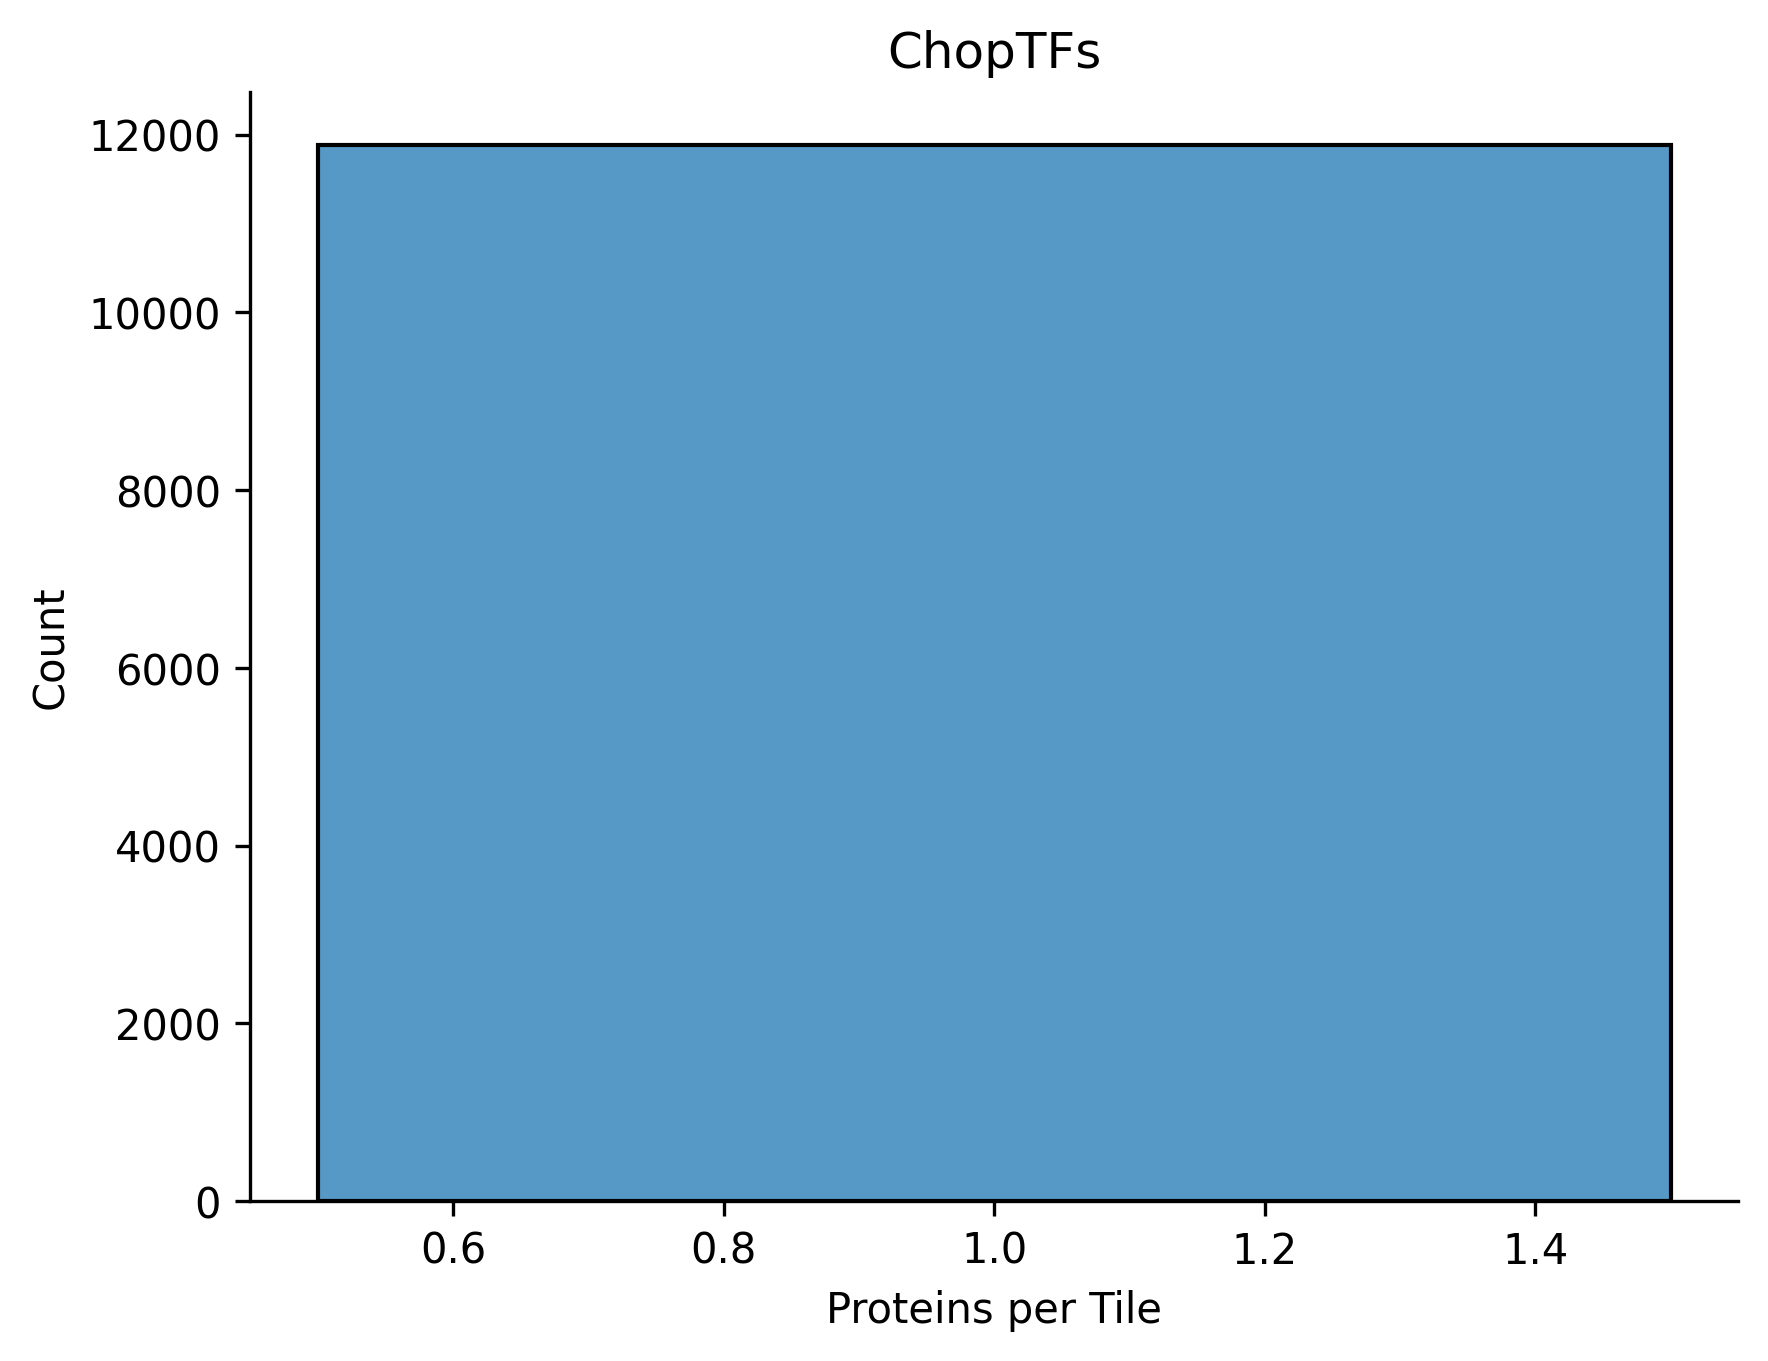

In [10]:
plt.figure(dpi = 300)
sns.histplot(proteins_per_seq["id"], discrete = True)
sns.despine()
plt.xlabel("Proteins per Tile")
plt.title("ChopTFs")

In [11]:
sanborn_ADs = pd.read_excel("/global/scratch/projects/fc_mvslab/OpenProjects/Sanjana/TREBL/data/sanborn_known_ADs_elife-68068-fig1-data2-v3.xlsx")
sanborn_ADs = sanborn_ADs.rename(columns = {"protein ID" : "uniprotID"})
sanborn_ADs

,protein,uniprotID,start,stop,maximal activation,maximal Z score,maximal fragment,sequence
0,GCN4,P03069,63,142,128.273405,11.910003,A_tiles_P03069:76,NLDFDFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTDSTPMFE...
1,GAL4,P04386,832,880,44.019965,9.285866,A_tiles_P04386:828,SKPLSPGWTDQTAYNAFGITTGMFNTTTMDDVYNYLFDDEDTPPNPKK
2,GAL4,P04386,146,199,59.660889,10.031831,A_controls-mean_GAL4,SIDSAAHHDNSTIPLDFMPRDALHGFDWSEEDDMSDGLPFLKTDPN...
3,ARG81,P05085,194,256,32.070085,8.508774,A_tiles_P05085:194,KGHVKTGILSANDGVPPTPNLLDYDWNNLNITGYEWISSELRDDAL...
4,ARG81,P05085,69,126,13.391200,6.366012,A_tiles_P05085:65,IPQNSPATTTNLSGSVDEPQYQRRNIDFVRYDEEYVYHEDMDDELT...
...,...,...,...,...,...,...,...,...
145,YRM1,Q12340,737,785,73.486889,10.543228,A_tiles_Q12340:733,SENASHNNETGPIETELAQTISNEFWTAYNLGWEELMSQPDYKYLFDT
146,YRM1,Q12340,184,241,21.275056,7.501859,A_tiles_Q12340:193,PLEKTGSDILQQVCNVLPSFEQSSKIITDFFNTELETNEVSEVLDK...
147,HAA1,Q12753,658,693,35.587427,8.764113,A_tiles_Q12753:641,DLPDTSPMSSIQTASPPSQLLTDQGFADLDNFMSS
148,HAA1,Q12753,274,335,28.366703,8.207702,A_tiles_Q12753:282,NSRVGEVSVPLEEYIPSDIDGVGRVTDKSSLVYDWPFDESIERNFS...


In [12]:
min(sanborn_ADs["maximal Z score"])

3.48846111960084

In [13]:
min(sanborn_ADs["sequence"].str.len())

22

In [14]:
sanborn_ADs["sequence"].str.len().value_counts().sort_index()

22      3
35     12
36      2
44      1
47      1
48     14
49      7
52     11
53     19
56      2
57      5
58      3
59      2
60      5
61      6
62     12
64      1
65      6
66      7
70      1
71      1
73      1
74      7
75      3
76      1
79      2
82      1
86      1
87      2
91      1
92      1
95      2
96      1
100     1
111     1
117     1
118     1
124     1
129     1
Name: sequence, dtype: int64

In [15]:
len(sanborn_ADs["uniprotID"].unique())

96

In [16]:
tiles = []

for _, row in sanborn_ADs.iterrows():
    tf_id = row["uniprotID"]
    seq = row["sequence"]

    for i in range(len(seq) - 39):   # 40-mer window
        tile = seq[i:i+40]
        tiles.append({
            "seq": tile,
            "uniprotID": tf_id,
            "tile_start": i + 1,
            "tile_end": i + 40
        })

sanborn_tiles_df = pd.DataFrame(tiles)
sanborn_tiles_df["sanborn"] = "yes"
sanborn_tiles_df

,seq,uniprotID,tile_start,tile_end,sanborn
0,NLDFDFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTD,P03069,1,40,yes
1,LDFDFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTDS,P03069,2,41,yes
2,DFDFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTDST,P03069,3,42,yes
3,FDFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTDSTP,P03069,4,43,yes
4,DFALPQTATAPDAKTVLPIPELDDAVVESFFSSSTDSTPM,P03069,5,44,yes
...,...,...,...,...,...
3209,SLQSSQSLDQNFSIPQSPPLSSMSFNFLTGNINETNQNHS,Q12753,18,57,yes
3210,LQSSQSLDQNFSIPQSPPLSSMSFNFLTGNINETNQNHSN,Q12753,19,58,yes
3211,QSSQSLDQNFSIPQSPPLSSMSFNFLTGNINETNQNHSNH,Q12753,20,59,yes
3212,SSQSLDQNFSIPQSPPLSSMSFNFLTGNINETNQNHSNHQ,Q12753,21,60,yes


In [17]:
len(sanborn_tiles_df["uniprotID"].unique())

85

In [18]:
merged_activities_with_sanborn = merged_activities.merge(
    sanborn_tiles_df[["seq", "sanborn"]],
    on="seq",
    how="left"
)
merged_activities_with_sanborn["sanborn"] = merged_activities_with_sanborn["sanborn"].fillna("no")
merged_activities_with_sanborn

,seq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error,id,tile_start,tile_end,last_start,tile_center,sanborn
0,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,30,0.181359,-0.139026,0.389268,ns,NaN,NaN,0.528294,YBR049C,616,656,770,635,no
1,AAAAAIQEQQQLLQQKQQDDDDAIAAAAAAASSSLGDNKD,30,0.183804,-0.135233,0.552276,ns,0.000081,0.990735,0.687510,YBR049C,591,631,770,610,no
2,AAAANNAAGPASYLSQLPQVQRYYPNNMNALSSLLDPSSA,30,-0.024335,-0.201789,0.173106,ns,-0.153538,0.667066,0.374895,YKL032C,221,261,557,240,no
3,AAAASTSKSAEKEKPVTKKELKRREKQALLEKKKKLLEIA,30,-0.143397,-0.257455,-0.000570,ns,-0.235565,0.000621,0.256885,YBR267W,56,96,353,75,no
4,AAAKLATSGVDNITPTPAFQRRSYDISMNSSFKILPTSQA,30,0.190791,-0.019787,0.498284,ns,0.025976,0.889604,0.518071,YKL062W,466,506,590,485,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11876,YYLNVGDISAIYGVRGRIVSMAQQLRLHRCPSAVLSVHSN,30,-0.355089,-0.462603,-0.202542,ns,-0.363663,0.000621,0.260061,YMR280C,531,571,1393,550,no
11877,YYLSSNIKDQEVTDWDLSTLNIPLDKAMNLLTAFKIHSDI,30,0.703368,0.521223,0.882161,ns,NaN,NaN,0.360938,YOR172W,596,636,746,615,no
11878,YYPANGDGTTNGATPSVTSNQVQNPNLEKTYSTFEQQQQH,30,-0.018907,-0.298519,0.256928,ns,-0.017897,0.965750,0.555447,YMR016C,171,211,745,190,no
11879,YYQYPLPSNNNTINYLPSVDVQYPLNVSPSSTSHPASEVI,30,0.553945,0.332200,0.759904,ns,0.556644,0.000621,0.427704,YPL230W,211,251,351,230,no


In [19]:
len(merged_activities_with_sanborn["id"].unique())

161

In [20]:
activator_ids = merged_activities_with_sanborn[merged_activities_with_sanborn["class"] == "activator"]["id"].unique()
len(activator_ids)

112

In [21]:
merged_activities_with_sanborn_activators = merged_activities_with_sanborn[merged_activities_with_sanborn["id"].isin(activator_ids)]
merged_activities_with_sanborn_activators = merged_activities_with_sanborn_activators.sort_values(by = ["id", "last_start"])
merged_activities_with_sanborn_activators

,seq,time,activity,ci_low,ci_hi,class,mean_diff,pval_fdr,error,id,tile_start,tile_end,last_start,tile_center,sanborn
253,ALFDVIVQRMRKGELWHGIFTMIQMEQMHSRIIKTLSITL,30,0.102826,-0.116562,0.268878,ns,NaN,NaN,0.385440,YAL051W,836,876,1007,855,no
287,AMKLLTEREVNESGKRSASPINTNNASGDSPDTKKQHKME,30,-0.725844,-1.015244,-0.453333,ns,-0.219307,0.211242,0.561910,YAL051W,126,166,1007,145,no
303,ANFSVEDIDELNRNIKKEIQISSGLKPPVNTIDLTNGEPF,30,0.586033,0.501576,0.731945,ns,NaN,NaN,0.230369,YAL051W,896,936,1007,915,no
438,ASENWCACANENIISCLLYIWSFFAFSPEEGDFFLEHPTD,30,0.428499,-0.016103,0.759183,ns,NaN,NaN,0.775285,YAL051W,451,491,1007,470,no
560,AVFLHFETLITKDKSIFPFYKKYFMVSCMDALSLINYFNK,30,0.048562,-0.134961,0.233084,ns,-0.143054,0.271540,0.368045,YAL051W,691,731,1007,710,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11479,VYIKCVTSLDTTISPPQPEIVTDSRLSLDSFLEVIKVFTV,30,0.186803,-0.165304,0.527062,ns,0.232772,0.469328,0.692367,YPR196W,241,281,430,260,no
11604,YDHNMKLEAWNILCDVSKFVFSLKHCNHKMFQRFSTKCQS,30,-0.099001,-0.300222,0.055597,ns,0.014028,0.986975,0.355819,YPR196W,406,446,430,425,no
11618,YDVHGPVIPMKALEIANALVDVVSKYDHNMKLEAWNILCD,30,0.411517,-0.160687,1.125879,ns,0.352830,0.290085,1.286567,YPR196W,381,421,430,400,no
11726,YLQPLRKRGPKSIGESNLERAAEIQMVTVNNNIMAAPVMY,30,0.196777,-0.013827,0.486479,ns,NaN,NaN,0.500307,YPR196W,36,76,430,55,no


# Counting intervals

In [22]:
def intervals_overlap(a_start, a_end, b_start, b_end):
    return (a_start <= b_end) and (b_start <= a_end)

In [23]:
def merge_intervals(df, min_len=None):
    merged = []
    for uid, group in df.groupby("id"):
        intervals = group[["tile_start", "tile_end"]].sort_values("tile_start").to_numpy()
        current_start, current_end = intervals[0]
        for start, end in intervals[1:]:
            if start < current_end:
                current_end = max(current_end, end)
            else:
                merged.append((uid, current_start, current_end))
                current_start, current_end = start, end
        merged.append((uid, current_start, current_end))
    
    merged = np.array(merged, dtype=object)
    
    if min_len is not None:
        lengths = merged[:, 2].astype(float) - merged[:, 1].astype(float)
        merged = merged[lengths >= min_len]
    
    return merged

In [24]:
sanborn = merged_activities_with_sanborn[merged_activities_with_sanborn["sanborn"] == "yes"].copy()

In [25]:
sanborn_merged = merge_intervals(sanborn)
len(sanborn_merged)

98

In [26]:
our_activators = merged_activities_with_sanborn[merged_activities_with_sanborn["class"] == "activator"].copy()
our_activators_merged = merge_intervals(our_activators)
len(our_activators_merged)

267

In [27]:
our_repressors = merged_activities_with_sanborn[merged_activities_with_sanborn["class"] == "repressor"].copy()
our_repressors_merged = merge_intervals(our_repressors)
len(our_repressors_merged)

13

In [28]:
def compare_intervals(a, b, names=("A", "B")):
    a = np.array(a)
    b = np.array(b)

    overlap_matrix = (
        (a[:, None, 0] == b[None, :, 0]) &
        (a[:, None, 1].astype(float) < b[None, :, 2].astype(float)) &
        (b[None, :, 1].astype(float) < a[:, None, 2].astype(float))  # fix here
    )

    a_overlap = overlap_matrix.any(axis=1).sum()
    b_overlap = overlap_matrix.any(axis=0).sum()
    a_missed  = len(a) - a_overlap
    b_missed  = len(b) - b_overlap

    print(f"{names[0]} intervals overlapping {names[1]}: {a_overlap} / {len(a)} ({100*a_overlap/len(a):.1f}%)")
    print(f"{names[0]} intervals missed by {names[1]}:  {a_missed} / {len(a)} ({100*a_missed/len(a):.1f}%)")
    print(f"{names[1]} intervals overlapping {names[0]}: {b_overlap} / {len(b)} ({100*b_overlap/len(b):.1f}%)")
    print(f"{names[1]} intervals missed by {names[0]}:  {b_missed} / {len(b)} ({100*b_missed/len(b):.1f}%)")

    return overlap_matrix


In [29]:
compare_intervals(our_activators_merged, sanborn_merged, names=("Our Activators", "Sanborn"));

Our Activators intervals overlapping Sanborn: 92 / 267 (34.5%)
Our Activators intervals missed by Sanborn:  175 / 267 (65.5%)
Sanborn intervals overlapping Our Activators: 90 / 98 (91.8%)
Sanborn intervals missed by Our Activators:  8 / 98 (8.2%)


In [30]:
compare_intervals(our_repressors_merged, sanborn_merged, names=("Our Repressors", "Sanborn"));

Our Repressors intervals overlapping Sanborn: 1 / 13 (7.7%)
Our Repressors intervals missed by Sanborn:  12 / 13 (92.3%)
Sanborn intervals overlapping Our Repressors: 1 / 98 (1.0%)
Sanborn intervals missed by Our Repressors:  97 / 98 (99.0%)


In [31]:
overlap_matrix = compare_intervals(our_activators_merged, our_repressors_merged, names=("Our Activators", "Our Repressors"));

Our Activators intervals overlapping Our Repressors: 4 / 267 (1.5%)
Our Activators intervals missed by Our Repressors:  263 / 267 (98.5%)
Our Repressors intervals overlapping Our Activators: 3 / 13 (23.1%)
Our Repressors intervals missed by Our Activators:  10 / 13 (76.9%)


In [32]:
overlap_matrix = compare_intervals(our_activators_merged, our_repressors_merged, names=("Activators", "Repressors"))

our_activators_overlapping_repressors = our_activators_merged[overlap_matrix.any(axis=1)]
our_activators_overlapping_repressors

Activators intervals overlapping Repressors: 4 / 267 (1.5%)
Activators intervals missed by Repressors:  263 / 267 (98.5%)
Repressors intervals overlapping Activators: 3 / 13 (23.1%)
Repressors intervals missed by Activators:  10 / 13 (76.9%)


array([['YDR216W', 401, 461],
       ['YIL101C', 291, 346],
       ['YPL248C', 76, 116],
       ['YPL248C', 141, 206]], dtype=object)

In [33]:
our_repressors_overlapping_activators = our_repressors_merged[overlap_matrix.any(axis=0)]
our_repressors_overlapping_activators

array([['YDR216W', 381, 421],
       ['YIL101C', 331, 371],
       ['YPL248C', 106, 146]], dtype=object)

In [34]:
# Per max slack 5/13/25
rds2_search = pd.DataFrame(our_activators_merged)
rds2_search[rds2_search[0] == "YPL133C"]

,0,1,2
250,YPL133C,101,171
251,YPL133C,261,301


# RD Overlap?

Ash1
Matα2
Mig1
Rap1
Rgt1
Rme1
Rox1
Ume6

YKL185W
YCR039C
YGL035C
YNL216W
YKL038W
YGR044C
YPR065W
YDR207C

In [35]:
RD_ids = ["YKL185W", "YCR039C", "YGL035C", "YNL216W", "YKL038W", "YGR044C", "YPR065W", "YDR207C"]
RD_ids

['YKL185W',
 'YCR039C',
 'YGL035C',
 'YNL216W',
 'YKL038W',
 'YGR044C',
 'YPR065W',
 'YDR207C']

In [36]:
our_repressors_merged_df = pd.DataFrame(our_repressors_merged)
our_repressors_merged_df

,0,1,2
0,YAR007C,456,496
1,YCR039C,76,116
2,YCR096C,66,106
3,YDL048C,121,171
4,YDL056W,36,76
5,YDR216W,381,421
6,YIL101C,331,371
7,YKL038W,576,616
8,YKL185W,341,381
9,YNL068C,411,451


In [37]:
our_repressors_merged_df[our_repressors_merged_df[0].isin(RD_ids)]

,0,1,2
1,YCR039C,76,116
7,YKL038W,576,616
8,YKL185W,341,381


# 1. Loess

In [38]:
import numpy as np
import pandas as pd
from collections import defaultdict, Counter
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import pearsonr

WINDOW = 40  # your tile size


# ------------------------------------------------------------
# 1. FIXED TILE EXPANSION (for overlap method)
# ------------------------------------------------------------
def build_overlap_profile(df):
    results = []

    for pid, g in df.groupby("id"):
        pos_vals = defaultdict(list)

        for _, r in g.iterrows():
            start = int(r["tile_start"])
            end = start + WINDOW - 1  # IMPORTANT FIX

            for p in range(start, end + 1):
                pos_vals[p].append(r["activity"])

        positions = np.array(sorted(pos_vals.keys()))
        values = np.array([np.mean(pos_vals[p]) for p in positions])

        results.append(pd.DataFrame({
            "id": pid,
            "position": positions,
            "activity_overlap": values
        }))

    return pd.concat(results, ignore_index=True)


# ------------------------------------------------------------
# 2. FIXED-K LOESS (matches "20 nearest points" idea)
# ------------------------------------------------------------
def loess_per_protein(df, k=5):
    out = []

    for pid, g in df.groupby("id"):
        g = g.sort_values("tile_center")

        x = g["tile_center"].values
        y = g["activity"].values

        frac = min(1.0, k / len(g))  # fixed-k approximation

        smooth = lowess(y, x, frac=frac, it=1, return_sorted=False)

        # clamp to observed range (paper step)
        smooth = np.clip(smooth, y.min(), y.max())

        out.append(pd.DataFrame({
            "id": pid,
            "tile_center": x,
            "activity_loess": smooth
        }))

    return pd.concat(out, ignore_index=True)


# ------------------------------------------------------------
# 3. EXPAND LOESS TO POSITION SCALE
# ------------------------------------------------------------
def expand_loess_to_positions(df_loess, df_raw):
    out = []

    for pid, g in df_loess.groupby("id"):
        raw = df_raw[df_raw["id"] == pid]

        min_pos = raw["tile_start"].min()
        max_pos = (raw["tile_start"] + WINDOW - 1).max()

        positions = np.arange(min_pos, max_pos + 1)

        x = g["tile_center"].values
        y = g["activity_loess"].values

        # extend domain to full tile coverage instead of just tile centers
        f = np.full_like(positions, np.nan, dtype=float)
        valid = (positions >= min_pos) & (positions <= max_pos)
        f[valid] = np.interp(positions[valid], x, y)

        out.append(pd.DataFrame({
            "id": pid,
            "position": positions,
            "activity_loess_pos": f
        }))

    return pd.concat(out, ignore_index=True)

# ------------------------------------------------------------
# 4. COVERAGE MASK (CRITICAL for fair comparison)
# ------------------------------------------------------------
def compute_coverage(df):
    cov = Counter()

    for _, r in df.iterrows():
        start = int(r["tile_start"])
        end = start + WINDOW - 1

        for p in range(start, end + 1):
            cov[p] += 1

    return cov


# ------------------------------------------------------------
# 5. MERGE + VALID CORRELATION
# ------------------------------------------------------------
def compare_methods(df, loess_pos, overlap_pos):
    merged = loess_pos.merge(overlap_pos, on=["id", "position"])

    results = []

    for pid, g in merged.groupby("id"):
        cov = compute_coverage(df[df["id"] == pid])

        # ---------------------------
        # DEFINE SHARED VALID DOMAIN
        # ---------------------------
        valid = g["position"].map(lambda p: cov[p] >= 2)
        g = g[valid].dropna()

        if len(g) < 10:
            continue

        x = g["activity_loess_pos"].values
        y = g["activity_overlap"].values

        # normalize per protein
        x = (x - x.mean()) / (x.std() + 1e-8)
        y = (y - y.mean()) / (y.std() + 1e-8)

        r, _ = pearsonr(x, y)

        results.append((pid, r))

    return pd.DataFrame(results, columns=["id", "pearson_r"])


def filter_to_high_confidence(overlap, loess_pos, df, min_coverage=2):
    cov_rows = []
    for _, r in df.iterrows():
        start = int(r["tile_start"])
        for p in range(start, start + WINDOW):
            cov_rows.append((r["id"], p))
    
    cov_df = (pd.DataFrame(cov_rows, columns=["id", "position"])
                .groupby(["id", "position"])
                .size()
                .reset_index(name="coverage"))  # explicit name, works all pandas versions

    overlap_hc = overlap.merge(cov_df, on=["id", "position"])
    overlap_hc = overlap_hc[overlap_hc["coverage"] >= min_coverage]

    loess_hc = loess_pos.merge(cov_df, on=["id", "position"])
    loess_hc = loess_hc[loess_hc["coverage"] >= min_coverage].dropna(subset=["activity_loess_pos"])

    return overlap_hc, loess_hc
    
# ------------------------------------------------------------
# 6. ONE-CALL PIPELINE
# ------------------------------------------------------------
def run_pipeline(df):
    overlap = build_overlap_profile(df)
    loess = loess_per_protein(df, k=5)
    loess_pos = expand_loess_to_positions(loess, df)
    summary = compare_methods(df, loess_pos, overlap)

    overlap_hc, loess_hc = filter_to_high_confidence(overlap, loess_pos, df)

    return overlap_hc, loess, loess_hc, summary

In [39]:
overlap, loess, loess_pos, summary = run_pipeline(merged_activities_with_sanborn)

(summary["pearson_r"] > 0.8).mean()

0.9503105590062112

In [40]:
summary[summary["pearson_r"] < 0.8]

,id,pearson_r
20,YCR097W,0.792693
26,YDL170W,0.737337
28,YDR043C,0.766218
34,YDR253C,0.298312
56,YGL013C,0.780331
77,YIR013C,0.468540
98,YKR034W,0.779416
114,YML027W,0.763052


In [41]:
summary[summary["pearson_r"] > 0.8].sort_values(by = "pearson_r")

,id,pearson_r
76,YIL131C,0.804203
157,YPR052C,0.804204
35,YDR259C,0.809134
111,YLR375W,0.815557
6,YBR033W,0.820461
...,...,...
140,YOR298C-A,0.974661
73,YIL036W,0.975935
42,YEL009C,0.975991
88,YKL015W,0.978860


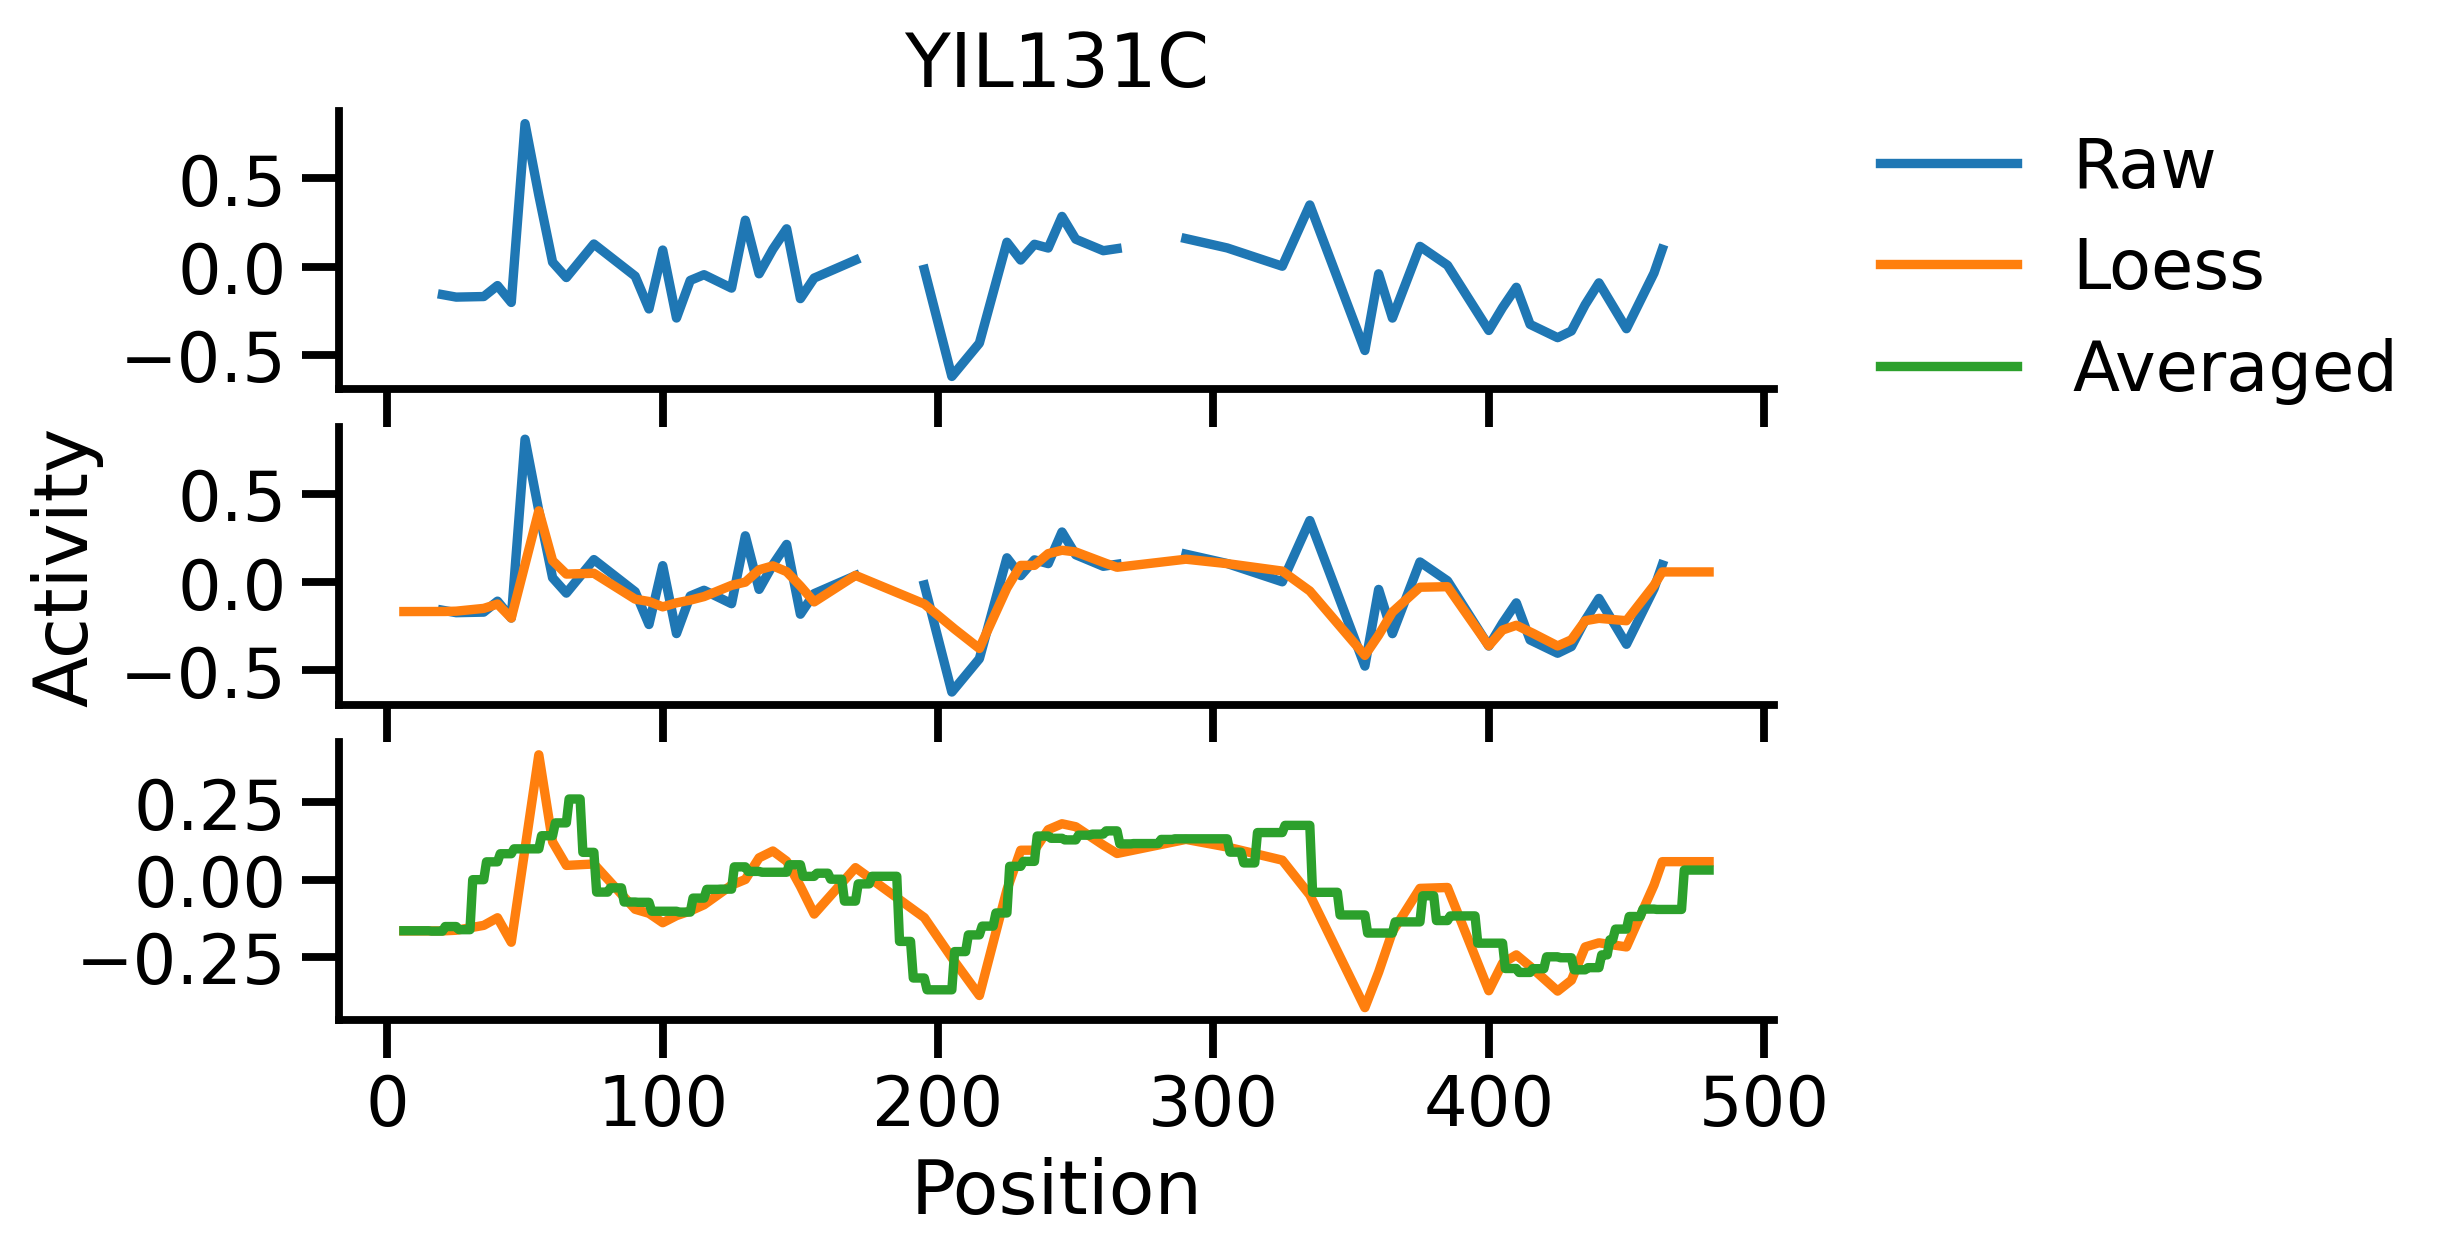

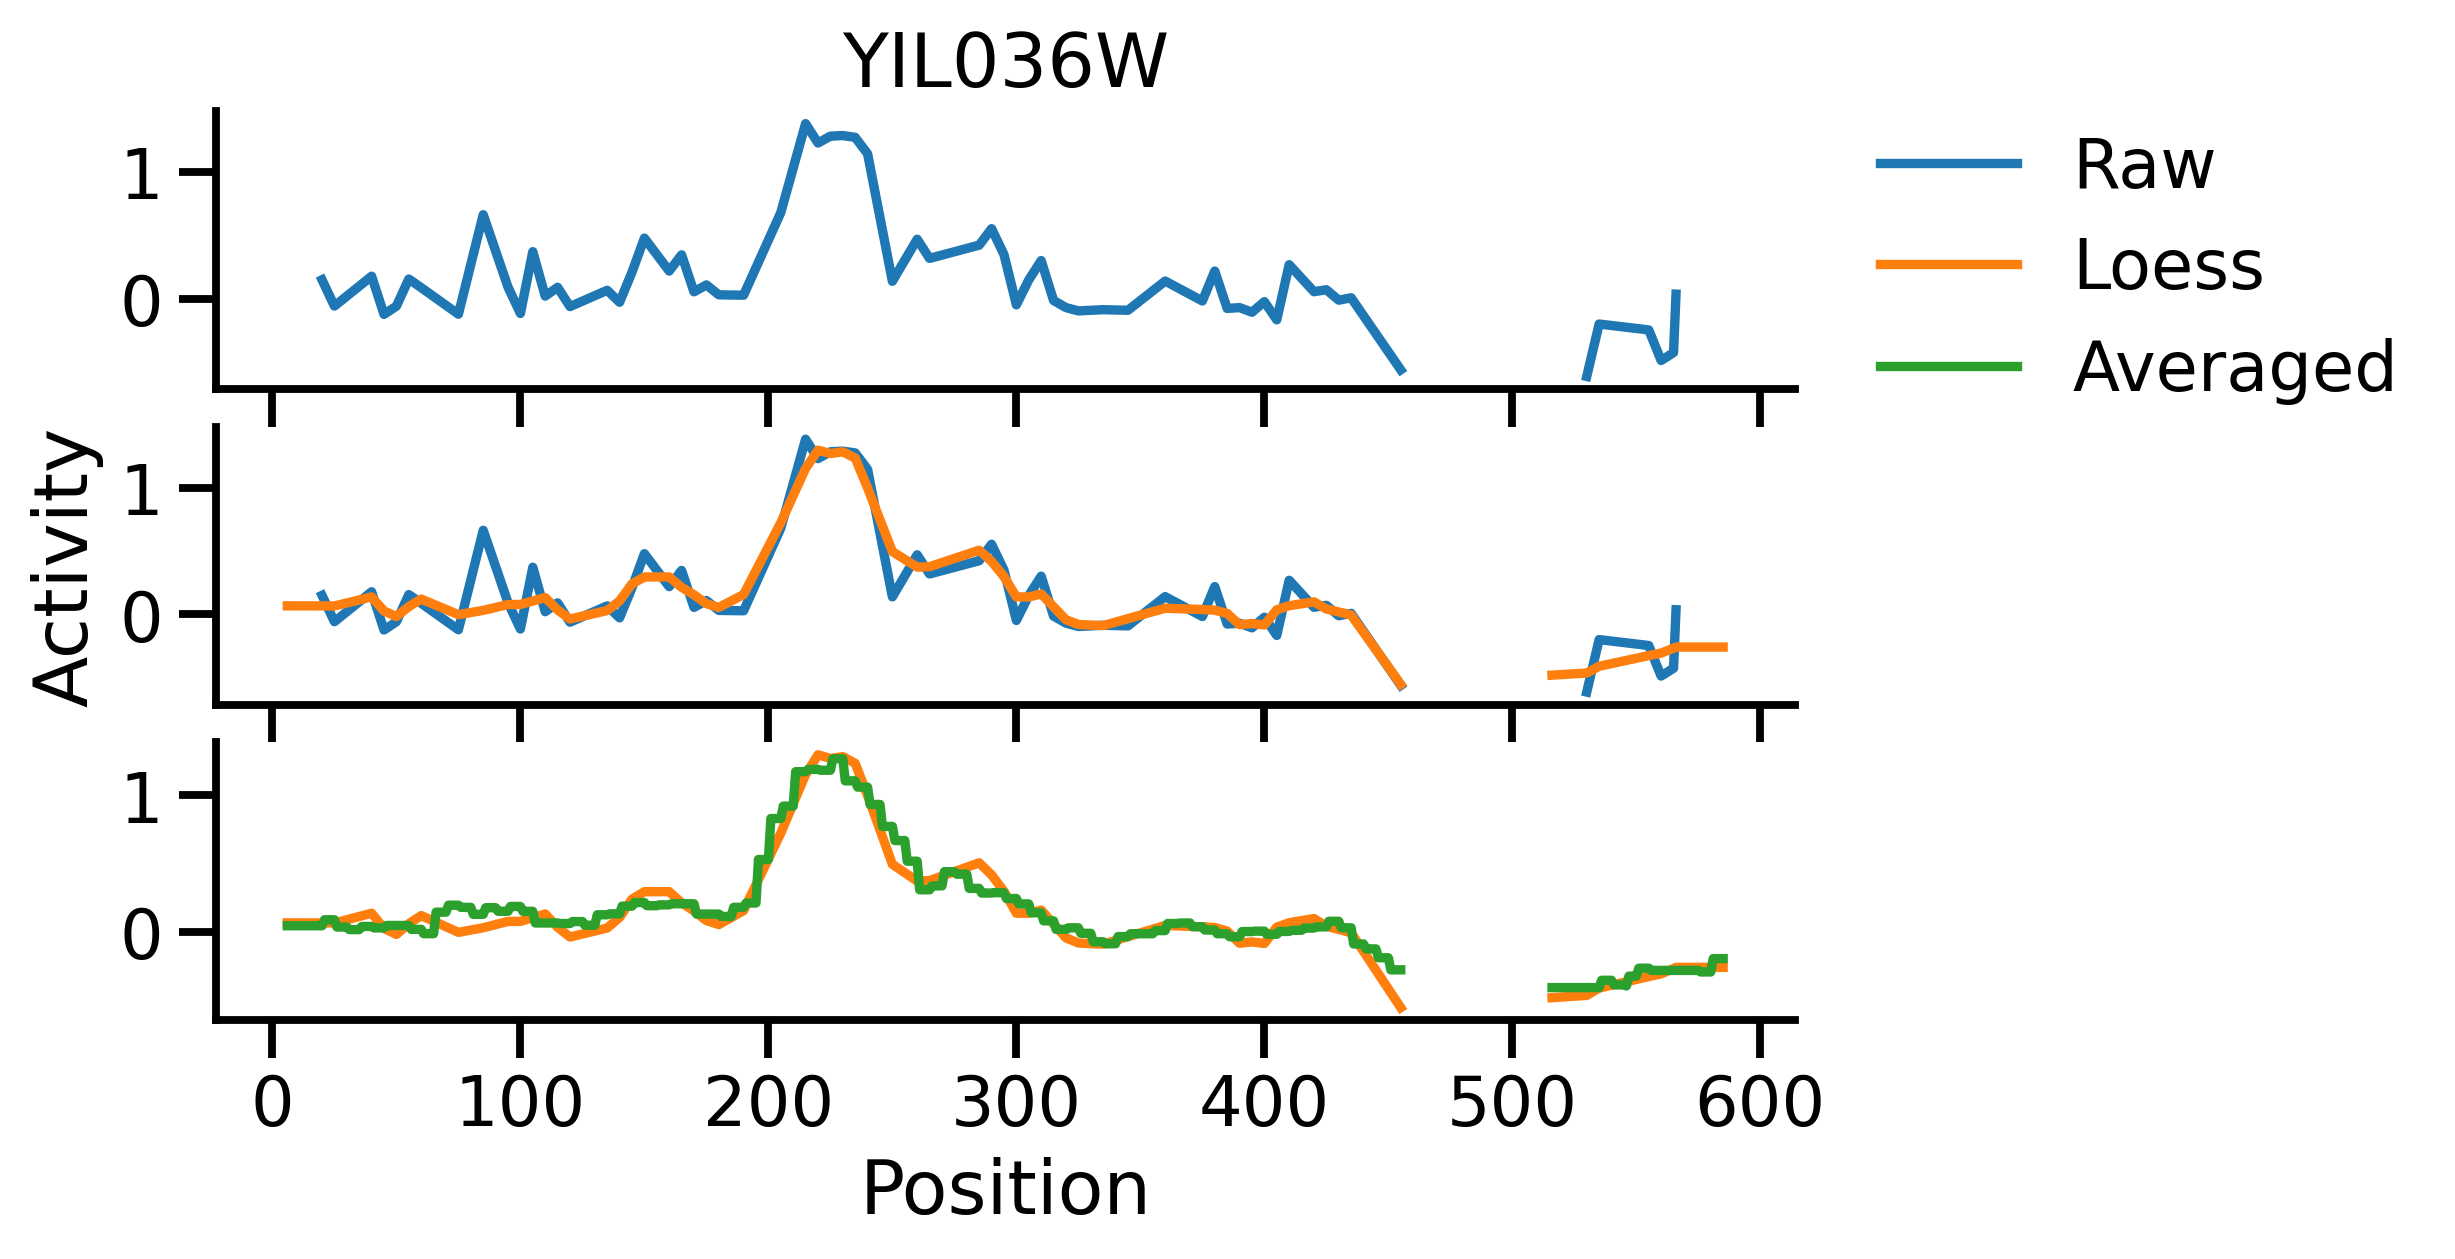

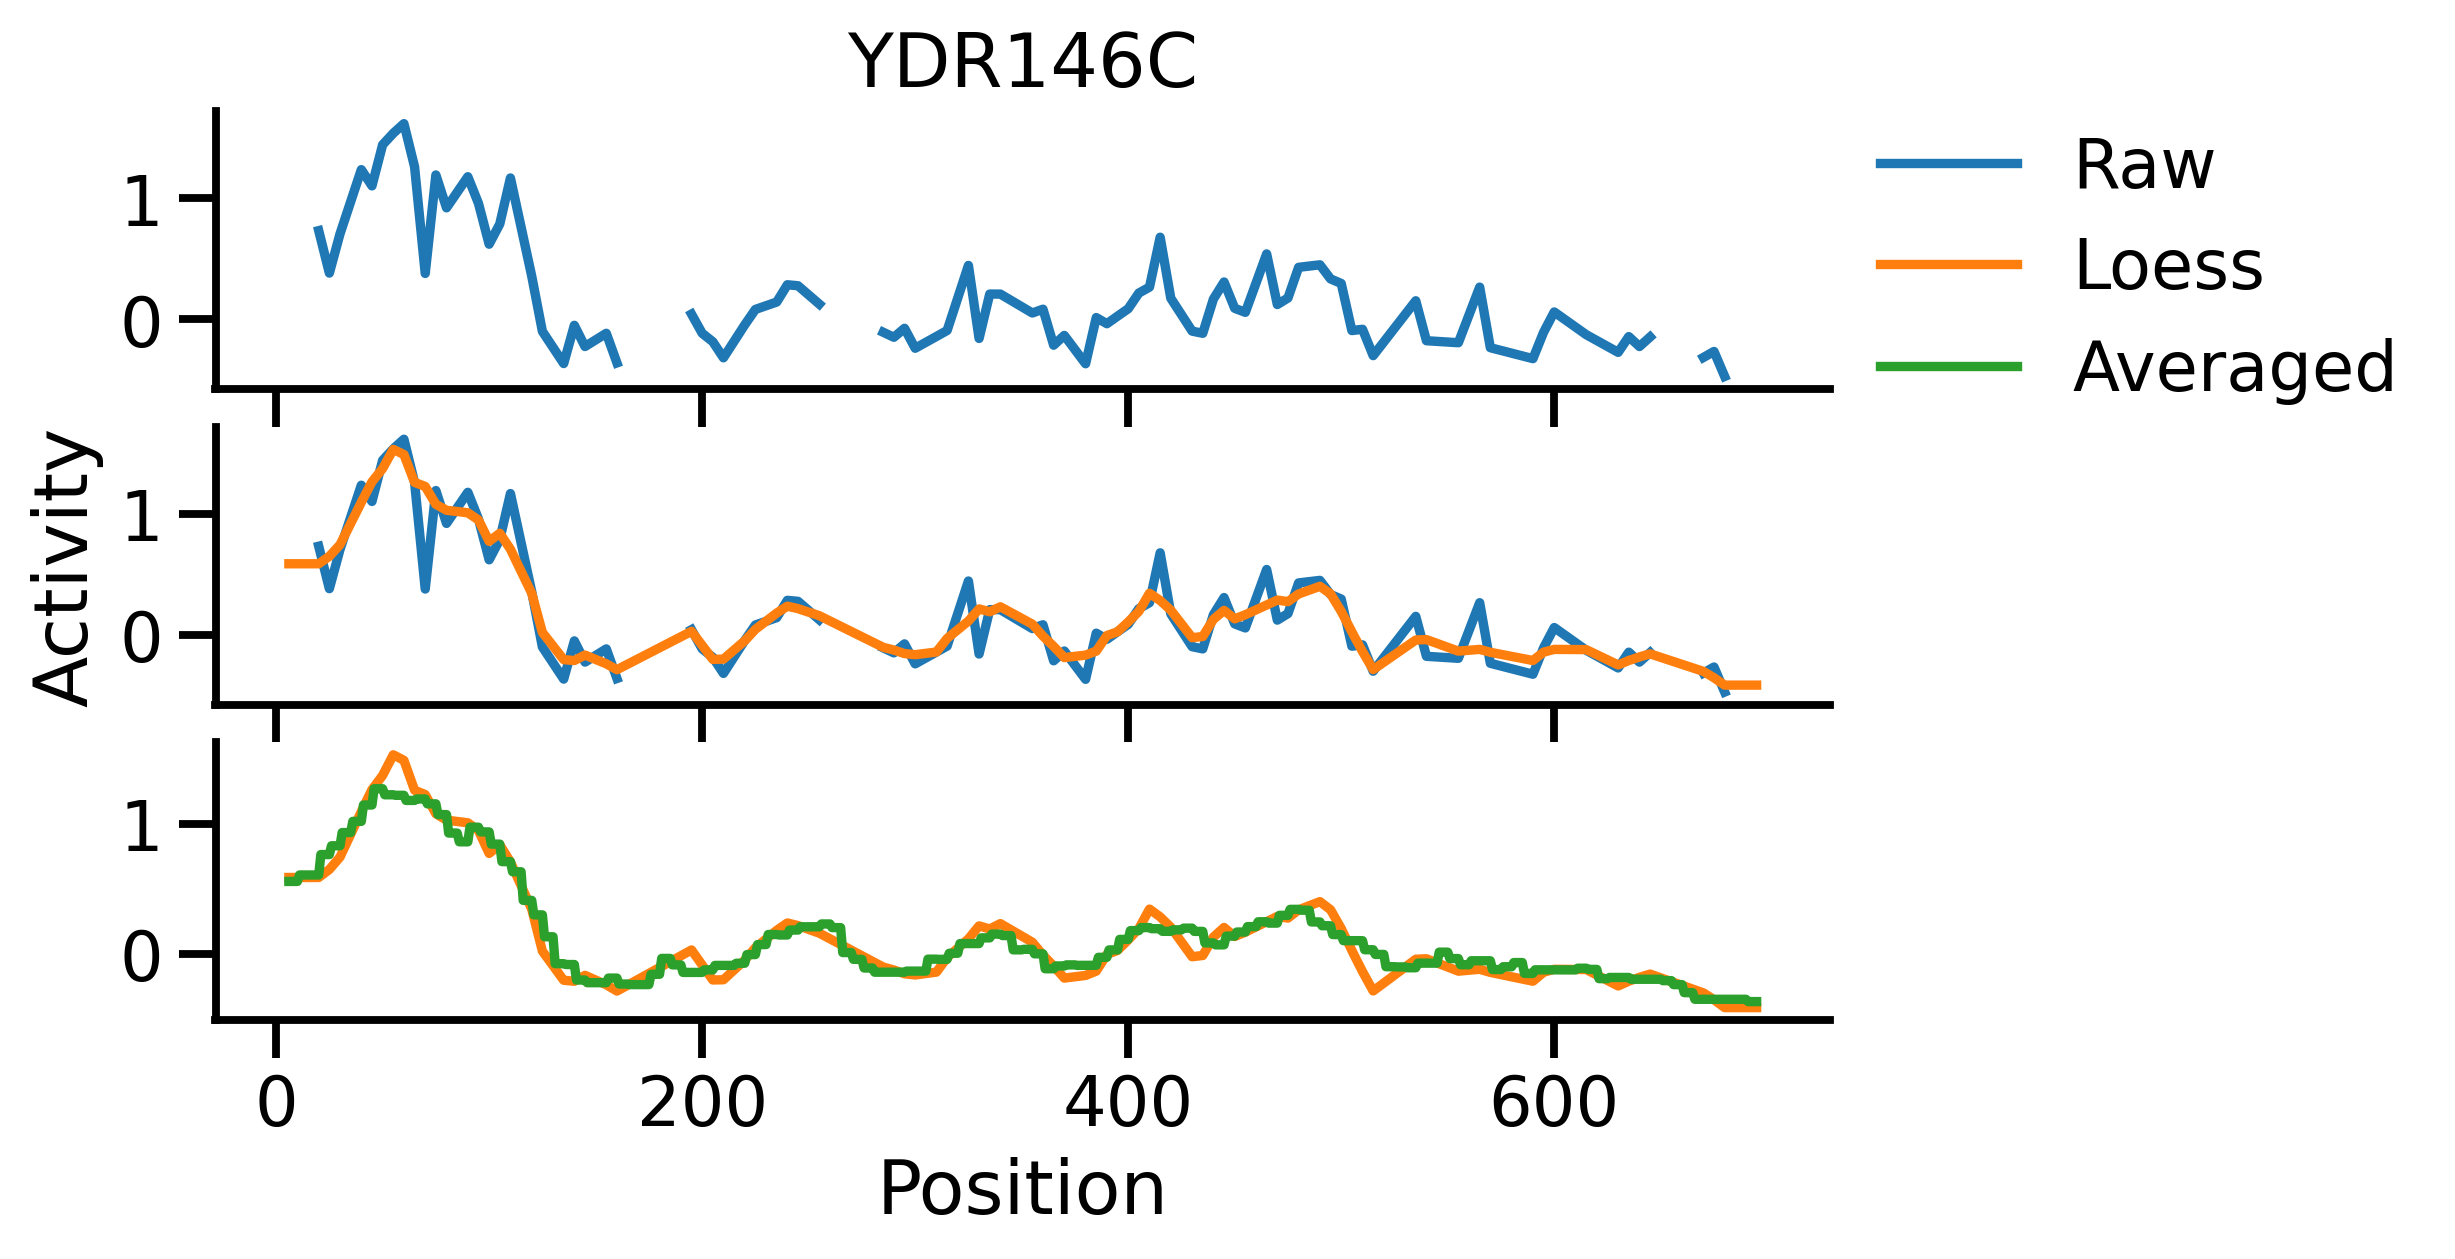

In [101]:
def split_continuous_segments(df, pos_col="position", gap=1):
    df = df.sort_values(pos_col).reset_index(drop=True)
    breaks = df[pos_col].diff() > gap
    segment_ids = breaks.cumsum()
    return [seg for _, seg in df.groupby(segment_ids)]

sns.set_context('talk')

for id in ["YIL131C", "YIL036W", "YDR146C"]:
    fig, axes = plt.subplots(3, 1, figsize=(6, 4), sharex=True, dpi=300)

    raw_data     = merged_activities_with_sanborn_activators[merged_activities_with_sanborn_activators["id"] == id]
    loess_data   = loess_pos[loess_pos["id"] == id].dropna()
    overlap_data = overlap[overlap["id"] == id].dropna()

    raw_segs     = split_continuous_segments(raw_data, pos_col="tile_center", gap=20)
    loess_segs   = split_continuous_segments(loess_data)
    overlap_segs = split_continuous_segments(overlap_data)

    # --- panel 1: raw only ---
    ax = axes[0]
    for i, seg in enumerate(raw_segs):
        sns.lineplot(data=seg, x="tile_center", y="activity",
                     color="C0", label="raw" if i == 0 else "_nolegend_", ax=ax)
    ax.set_ylabel("Activity")
    ax.set_xlabel("")
    ax.set_title(id)
    ax.get_legend().remove()

    # --- panel 2: raw + loess ---
    ax = axes[1]
    for i, seg in enumerate(raw_segs):
        sns.lineplot(data=seg, x="tile_center", y="activity",
                     color="C0", label="raw" if i == 0 else "_nolegend_", ax=ax)
    for i, seg in enumerate(loess_segs):
        sns.lineplot(data=seg, x="position", y="activity_loess_pos",
                     color="C1", label="loess" if i == 0 else "_nolegend_", ax=ax)
    ax.set_ylabel("Activity")
    ax.set_xlabel("")
    ax.get_legend().remove()

    # --- panel 3: loess + averaged ---
    ax = axes[2]
    for i, seg in enumerate(loess_segs):
        sns.lineplot(data=seg, x="position", y="activity_loess_pos",
                     color="C1", label="loess" if i == 0 else "_nolegend_", ax=ax)
    for i, seg in enumerate(overlap_segs):
        sns.lineplot(data=seg, x="position", y="activity_overlap",
                     color="C2", label="averaged" if i == 0 else "_nolegend_", ax=ax)
    ax.set_ylabel("Activity")
    ax.set_xlabel("Position")
    ax.get_legend().remove()

    # --- single figure legend ---
    from matplotlib.lines import Line2D
    legend_handles = [
        Line2D([0], [0], color="C0", label="Raw"),
        Line2D([0], [0], color="C1", label="Loess"),
        Line2D([0], [0], color="C2", label="Averaged"),
    ]
    fig.legend(handles=legend_handles, loc="center right",
               bbox_to_anchor=(1.35, 0.8), frameon=False)

    axes[0].set_ylabel("")
    axes[2].set_ylabel("")
    
    sns.despine()
    plt.tight_layout(pad=0)
    plt.show()

# Plotting heatmap

In [102]:
import numpy as np
import pandas as pd
from collections import Counter

WINDOW = 40


def build_heatmap_matrix_sorted(loess_pos_df, df_raw):
    id_order = (
        df_raw.groupby("id")["last_start"]
        .max()
        .sort_values(ascending=False)
        .index
    )

    pivot = (loess_pos_df
             .pivot(index="id", columns="position", values="activity_loess_pos")
             .reindex(id_order))

    pivot.columns.name = None
    return pivot

In [103]:
mat = build_heatmap_matrix_sorted(loess_pos, merged_activities_with_sanborn)

In [104]:
mat

,6,7,8,9,10,11,12,13,14,15,...,1486,1487,1488,1489,1490,1491,1492,1493,1494,1495
id,,,,,,,,,,,,,,,,,,,,,
YLR256W,0.274779,0.274779,0.274779,0.274779,0.274779,0.274779,0.274779,0.274779,0.274779,0.274779,...,0.050438,0.050438,0.050438,0.050438,0.050438,0.050438,0.050438,0.050438,0.050438,0.050438
YMR280C,-0.186426,-0.186426,-0.186426,-0.186426,-0.186426,-0.186426,-0.186426,-0.186426,-0.186426,-0.186426,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YCR042C,0.030667,0.030667,0.030667,0.030667,0.030667,0.030667,0.030667,0.030667,0.030667,0.030667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YJR127C,0.072561,0.072561,0.072561,0.072561,0.072561,0.072561,0.072561,0.072561,0.072561,0.072561,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YLR278C,NaN,NaN,NaN,NaN,NaN,-0.148062,-0.148062,-0.148062,-0.148062,-0.148062,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YJL173C,0.269463,0.269463,0.269463,0.269463,0.269463,0.269463,0.269463,0.269463,0.269463,0.269463,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YIR013C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YCR096C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [105]:
import matplotlib.colors as mcolors
import matplotlib as mpl

def make_vlag_dark_center(dark_gray="#eeeeee", n=256):
    vlag = mpl.cm.get_cmap("vlag", n)
    colors = vlag(np.linspace(0, 1, n))
    
    # replace the middle portion with a gradient through dark gray
    mid = n // 2
    width = n // 6  # how wide the dark center region is — increase to widen it
    
    center_color = mcolors.to_rgba(dark_gray)
    
    for i in range(mid - width, mid + width):
        t = abs(i - mid) / width  # 0 at center, 1 at edges
        colors[i] = (
            t * colors[i][0] + (1 - t) * center_color[0],
            t * colors[i][1] + (1 - t) * center_color[1],
            t * colors[i][2] + (1 - t) * center_color[2],
            1.0
        )
    
    return mcolors.LinearSegmentedColormap.from_list("vlag_dark", colors)

cmap = make_vlag_dark_center(dark_gray="#eeeeee")

/tmp/ipykernel_2169218/3554710520.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  vlag = mpl.cm.get_cmap("vlag", n)


In [106]:
def plot_heatmap(
    mat,
    should_add_boxes=True,
    ADs=our_activators_merged,
    RDs=our_repressors_merged,
    save_path=None,
):
    fig, ax = plt.subplots(figsize=(14, 10), dpi=300)

    sns.heatmap(
        mat,
        cmap=cmap,
        mask=mat.isna(),
        center=0,
        vmin=mat.stack().quantile(0),
        vmax=mat.stack().quantile(1),
        ax=ax,
    )

    row_lookup = {pid: i for i, pid in enumerate(mat.index)}
    col_positions = np.array(mat.columns)

    for i in range(1, len(mat) - 1):
        ax.axhline(i, color="white", linewidth=0.5, zorder=1)

    def add_boxes(regions, color):
        for pid, start, end in regions:
            if pid not in row_lookup:
                continue

            row = row_lookup[pid]

            col_start = np.searchsorted(col_positions, int(start))
            col_end = np.searchsorted(col_positions, int(end))

            ax.add_patch(
                plt.Rectangle(
                    (col_start, row),
                    col_end - col_start,
                    1,
                    fill=False,
                    edgecolor=color,
                    linewidth=0.75,
                    zorder=3,
                )
            )

    if should_add_boxes:
        if ADs is not None:
            add_boxes(ADs, color="red")

        if RDs is not None:
            add_boxes(RDs, color="blue")

        add_boxes(sanborn_merged, color="green")

    # -----------------------------
    # scale bar
    # -----------------------------
    scale_bp = 200
    n_cols = len(col_positions)

    start_pos = col_positions[0]
    end_pos = start_pos + scale_bp

    col_start = np.searchsorted(col_positions, start_pos)
    col_end = np.searchsorted(col_positions, end_pos)

    scale_cols = col_end - col_start

    bar_y = len(mat) - 20
    bar_x = n_cols * 0.75

    tick_height = 0.3

    ax.plot(
        [bar_x, bar_x + scale_cols],
        [bar_y, bar_y],
        color="black",
        linewidth=2,
        clip_on=False,
    )

    ax.plot(
        [bar_x, bar_x],
        [bar_y - tick_height, bar_y + tick_height],
        color="black",
        linewidth=2,
        clip_on=False,
    )

    ax.plot(
        [bar_x + scale_cols, bar_x + scale_cols],
        [bar_y - tick_height, bar_y + tick_height],
        color="black",
        linewidth=2,
        clip_on=False,
    )

    ax.text(
        bar_x + scale_cols / 2,
        bar_y - 1,
        f"{scale_bp} AAs",
        ha="center",
        va="bottom",
        fontsize="medium",
        clip_on=False,
    )

    # -----------------------------
    # axis cleanup
    # -----------------------------
    ax.set_xticks([])
    ax.set_xlabel("")

    if should_add_boxes:
        from matplotlib.patches import Patch

        ax.legend(
            handles=[
                Patch(
                    facecolor="none",
                    edgecolor="green",
                    label="Sanborn Activation Domains",
                ),
                Patch(
                    facecolor="none",
                    edgecolor="red",
                    label="Chop TFs Activation Domains",
                ),
                Patch(
                    facecolor="none",
                    edgecolor="blue",
                    label="Chop TFs Repression Domains",
                ),
            ],
            loc="lower right",
        )

    plt.ylabel("")
    plt.yticks([])

    # -----------------------------
    # save
    # -----------------------------
    if save_path is not None:
        fig.savefig(
            f"{save_path}.png",
            dpi=300,
            bbox_inches="tight",
        )

        fig.savefig(
            f"{save_path}.pdf",
            bbox_inches="tight",
        )

    plt.show()

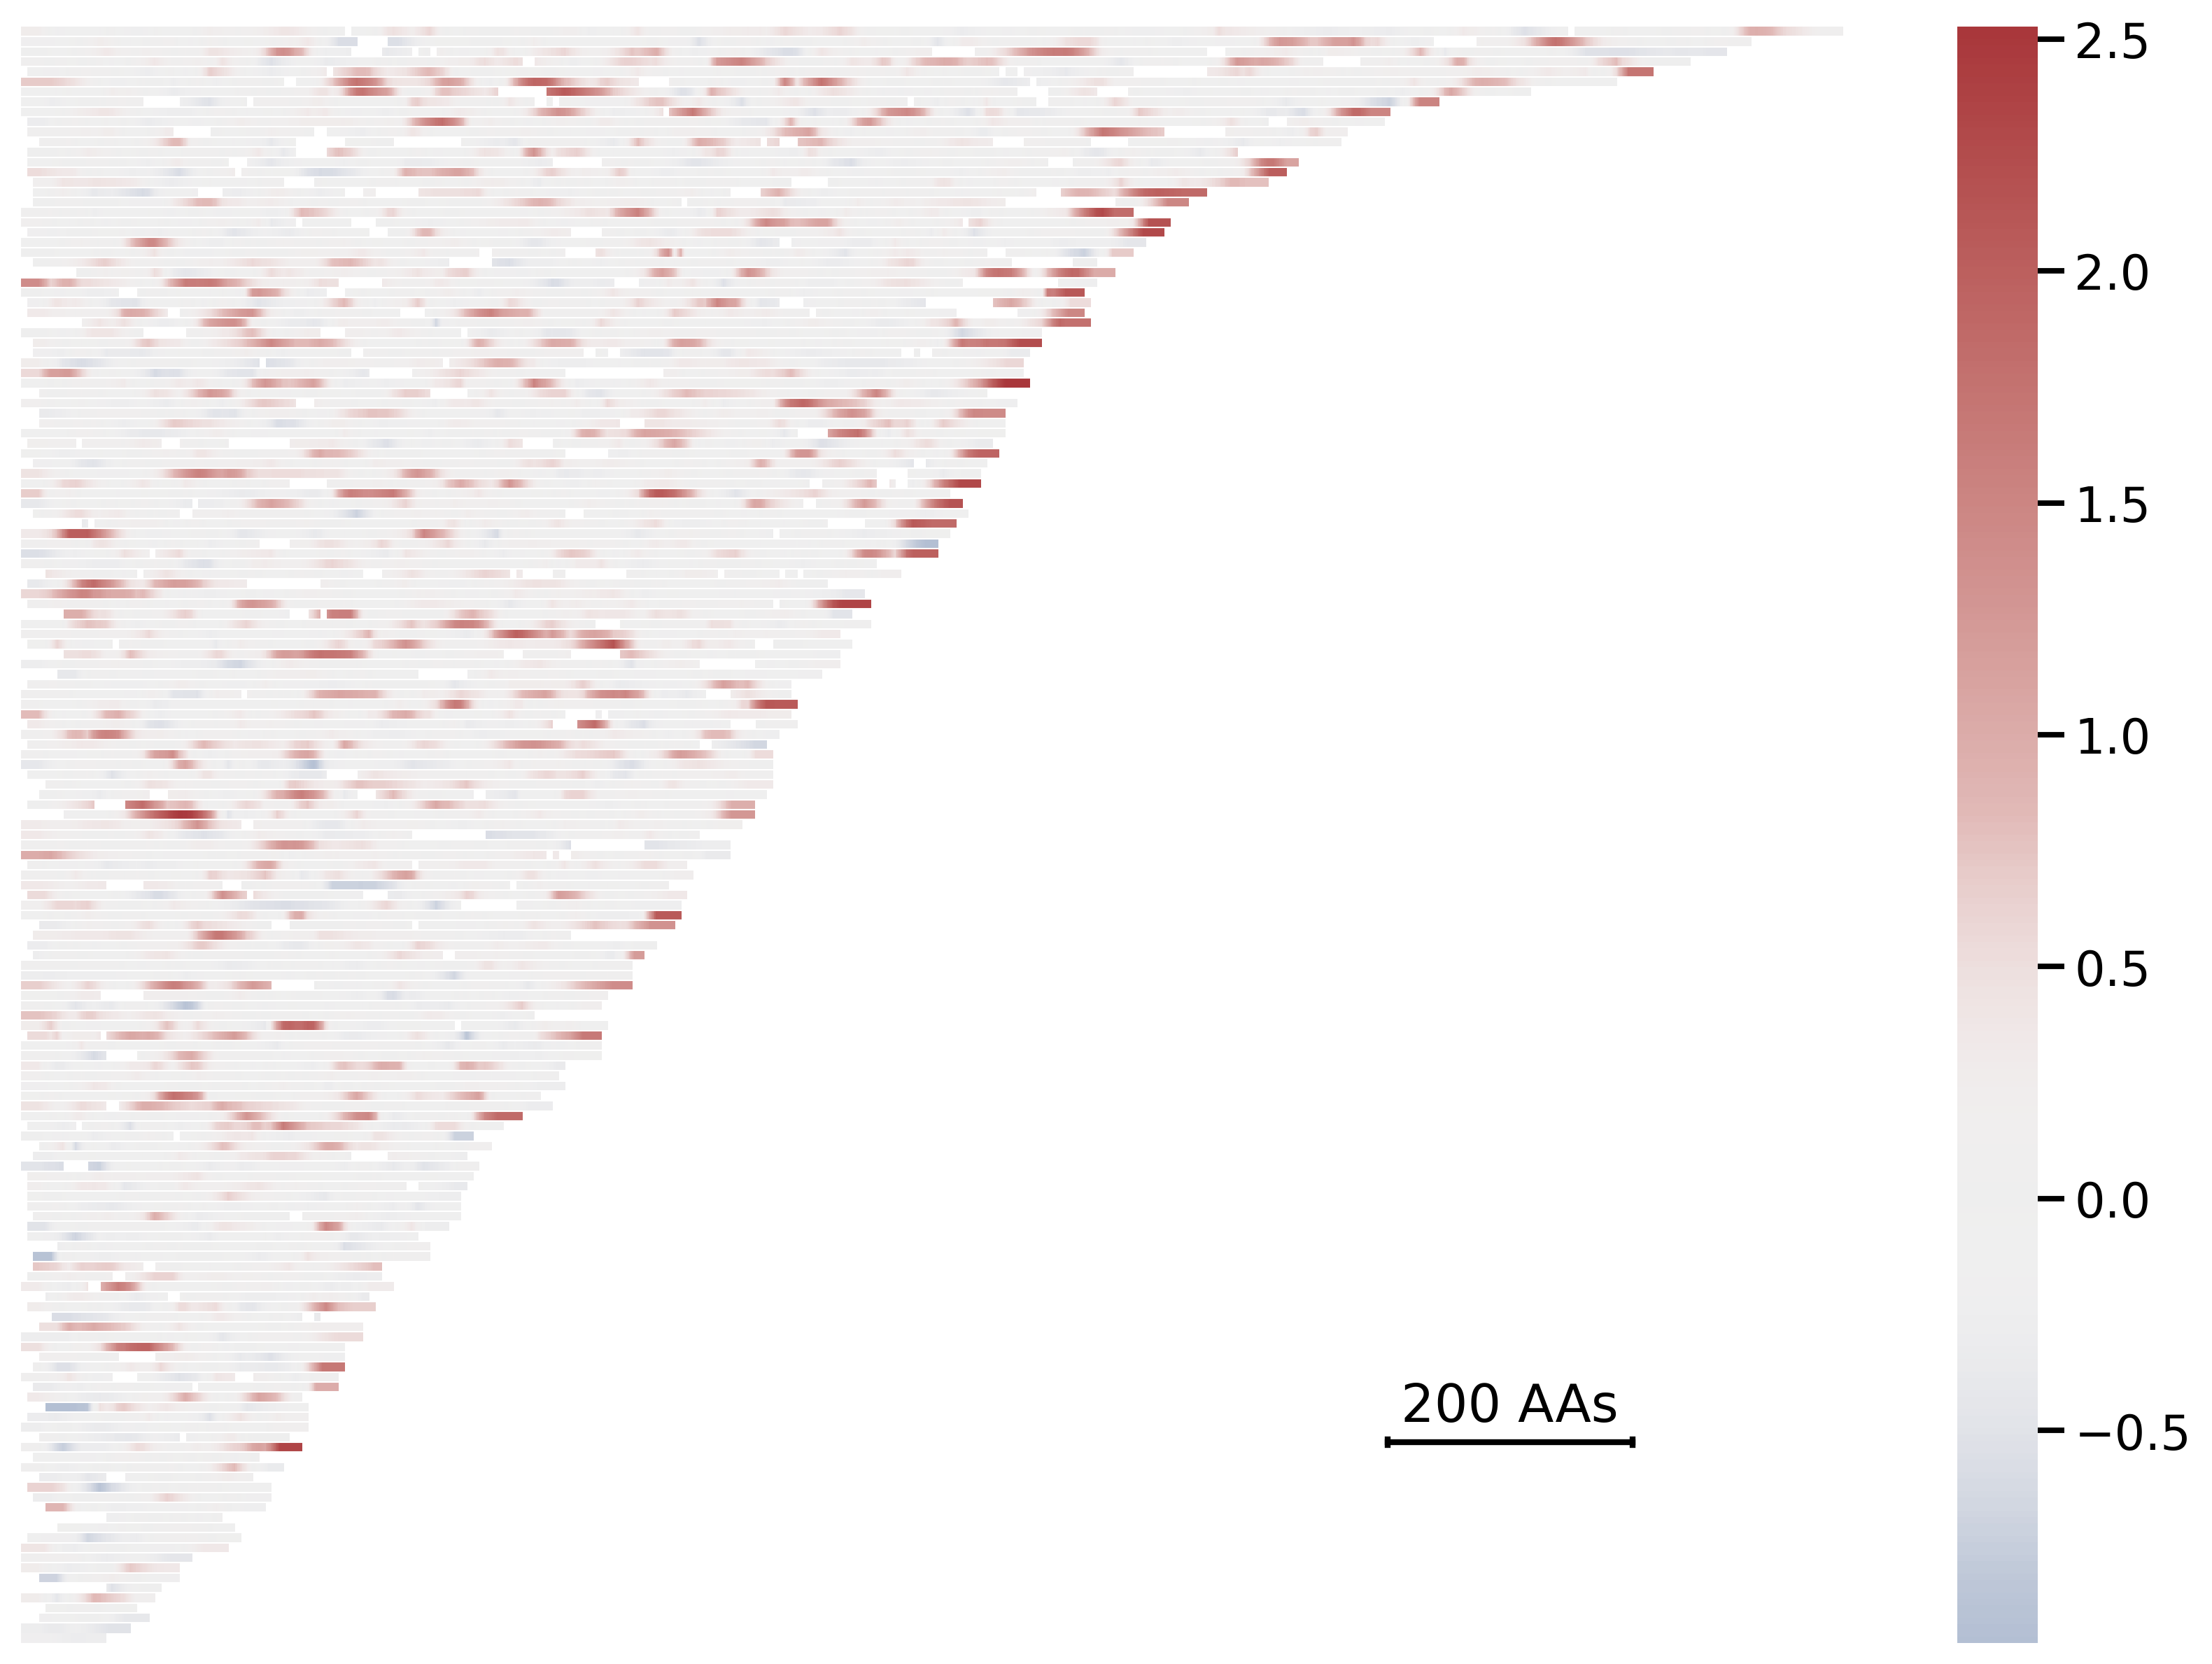

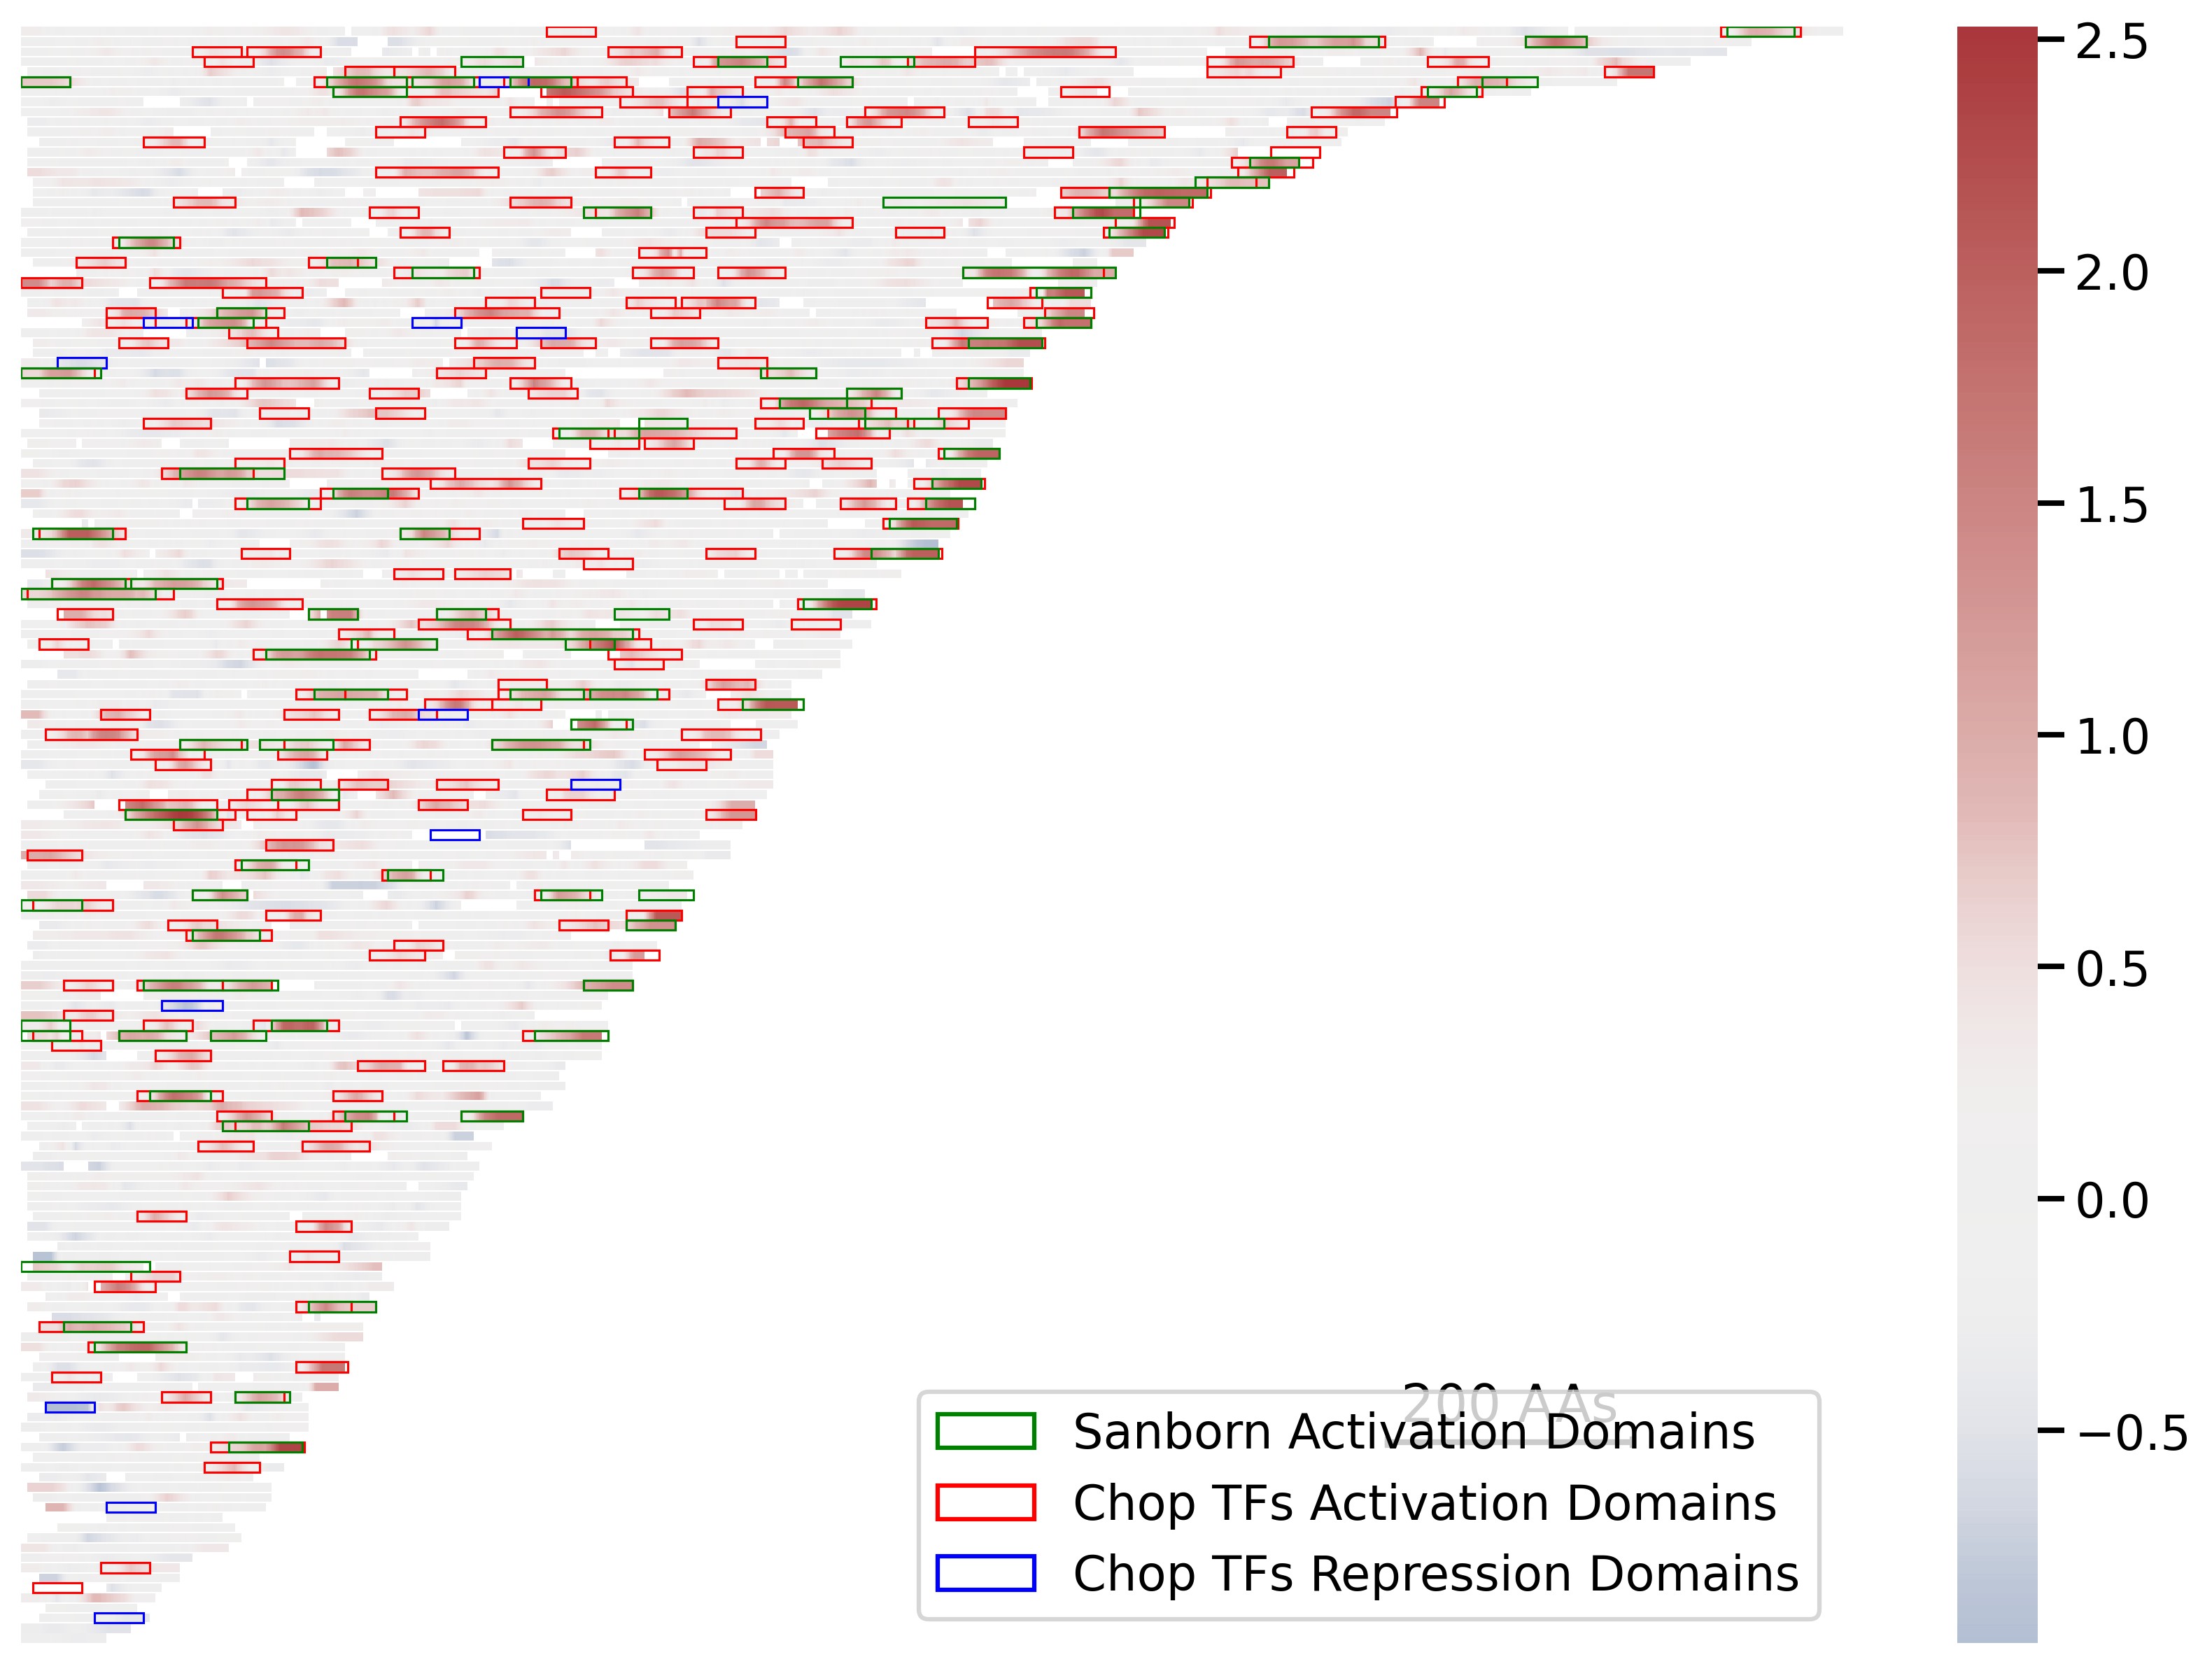

In [107]:
plot_heatmap(mat, should_add_boxes=False)
plot_heatmap(mat)

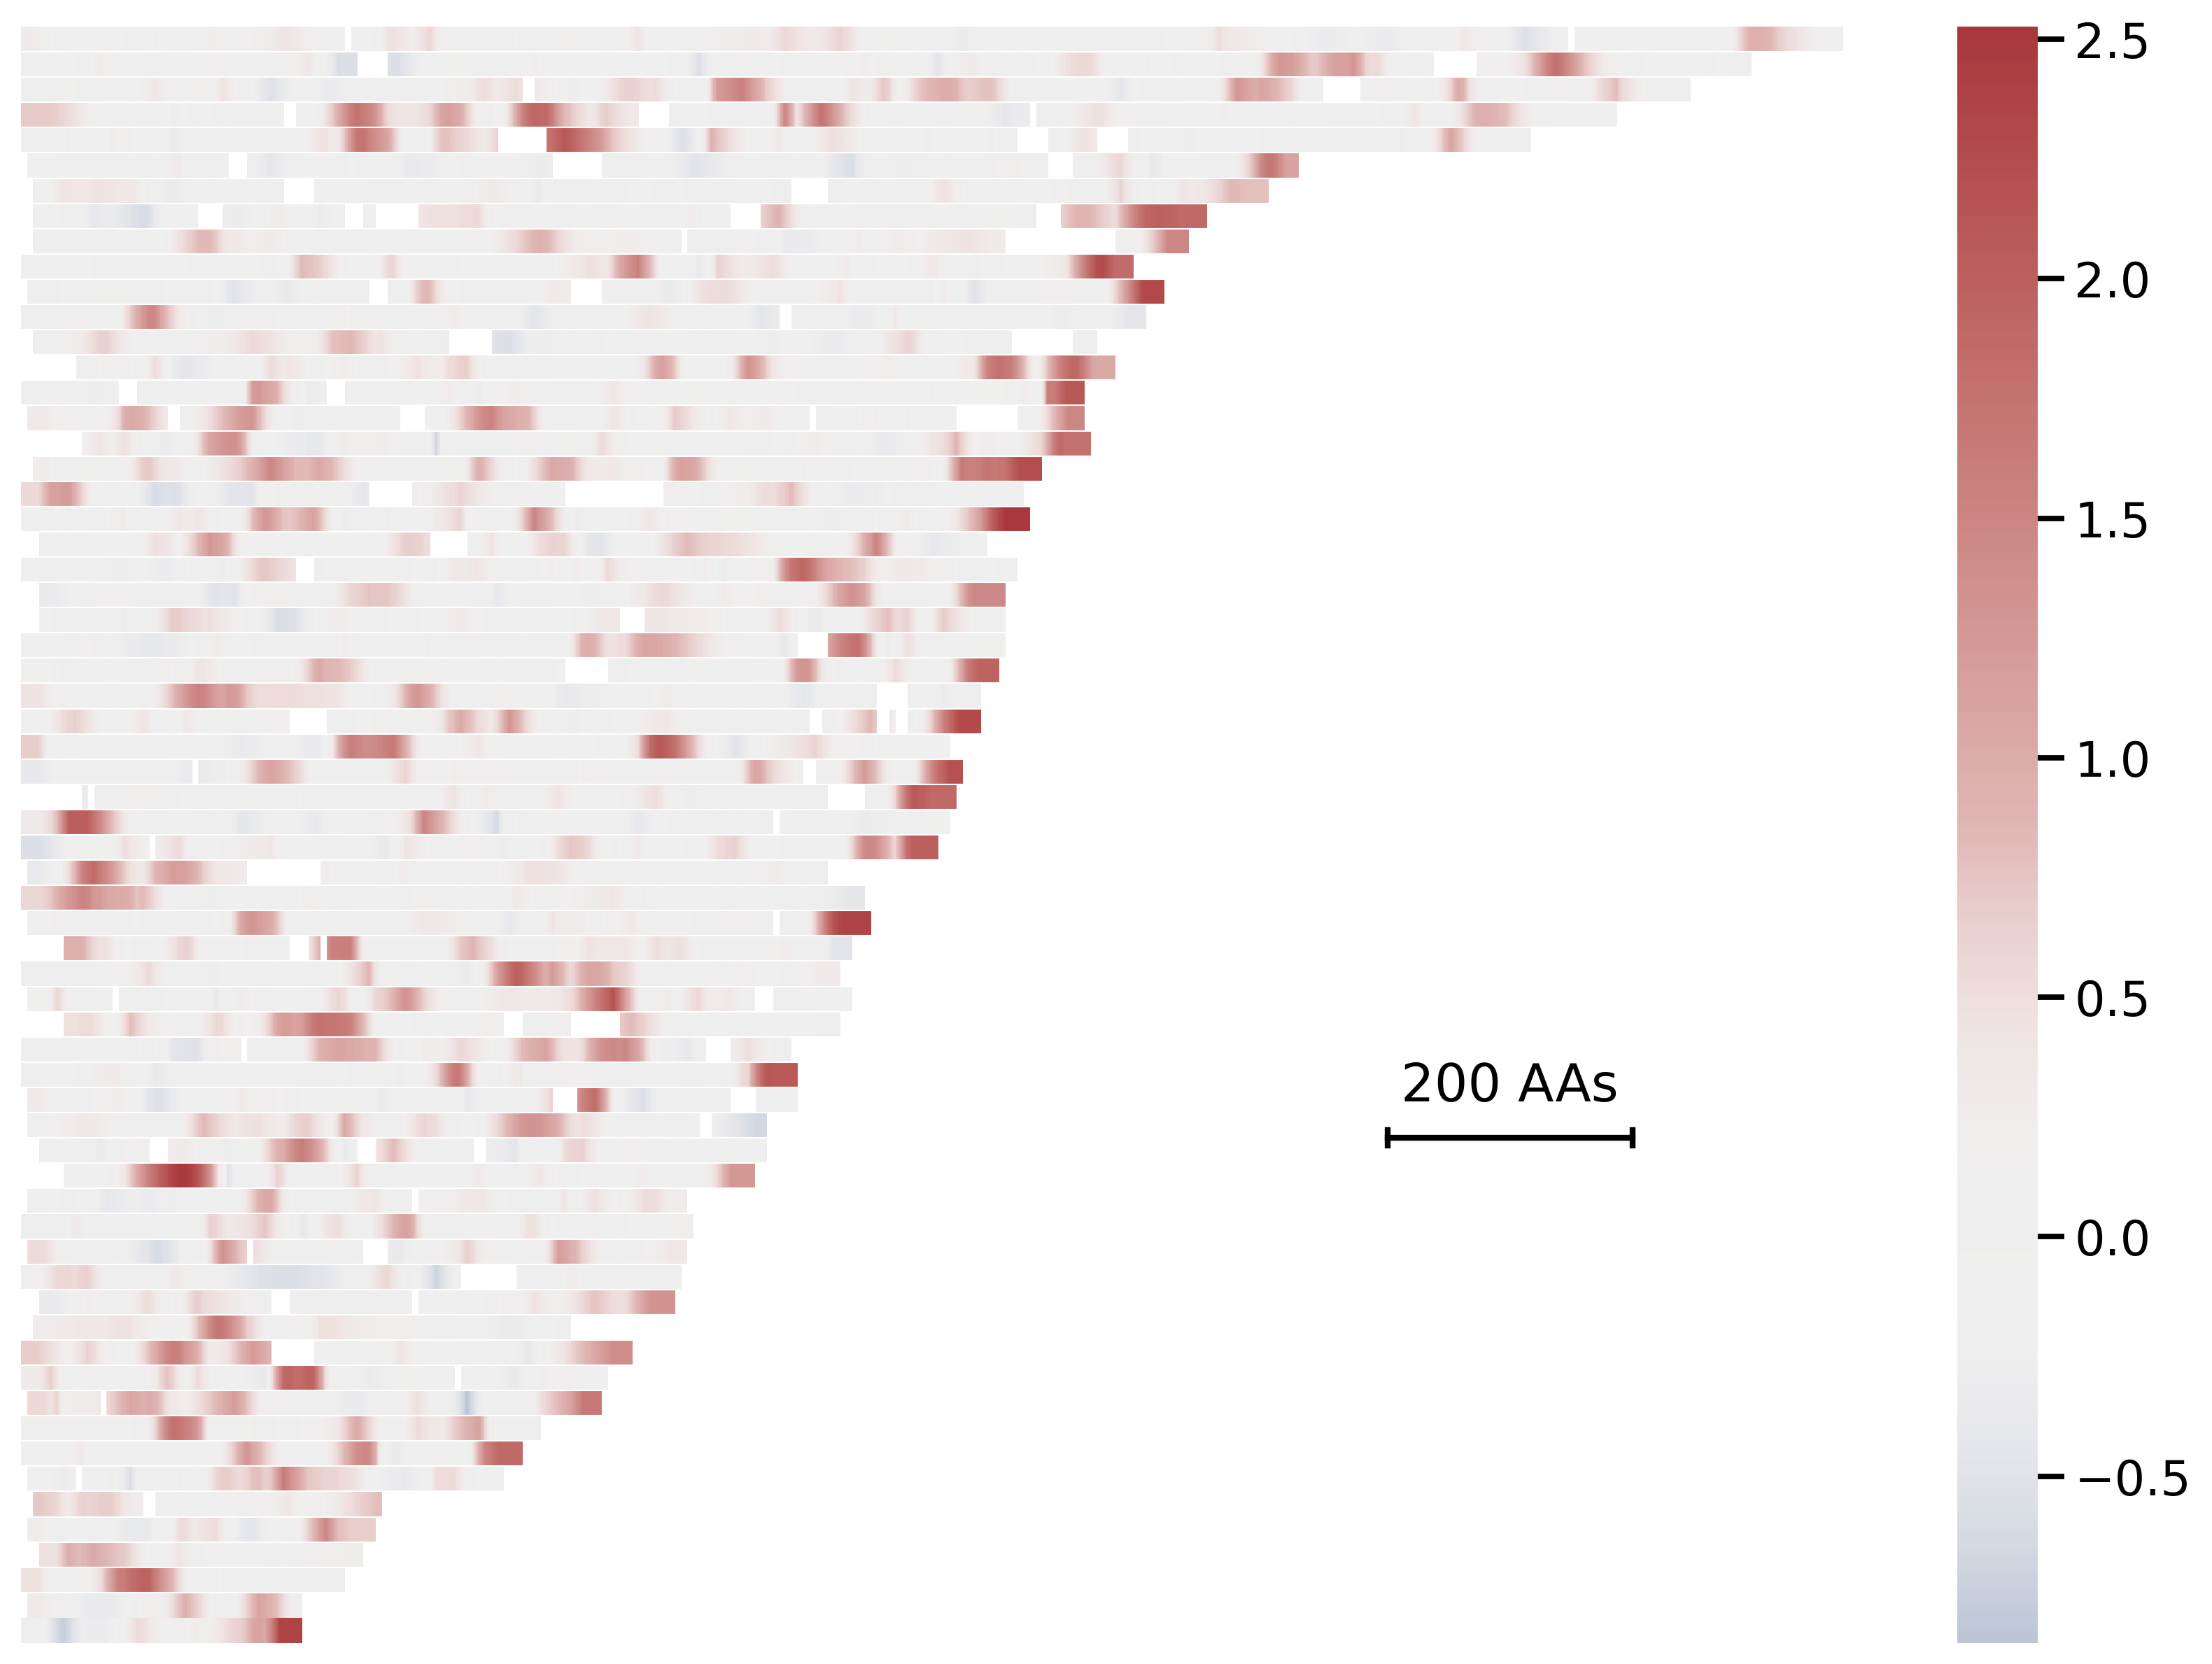

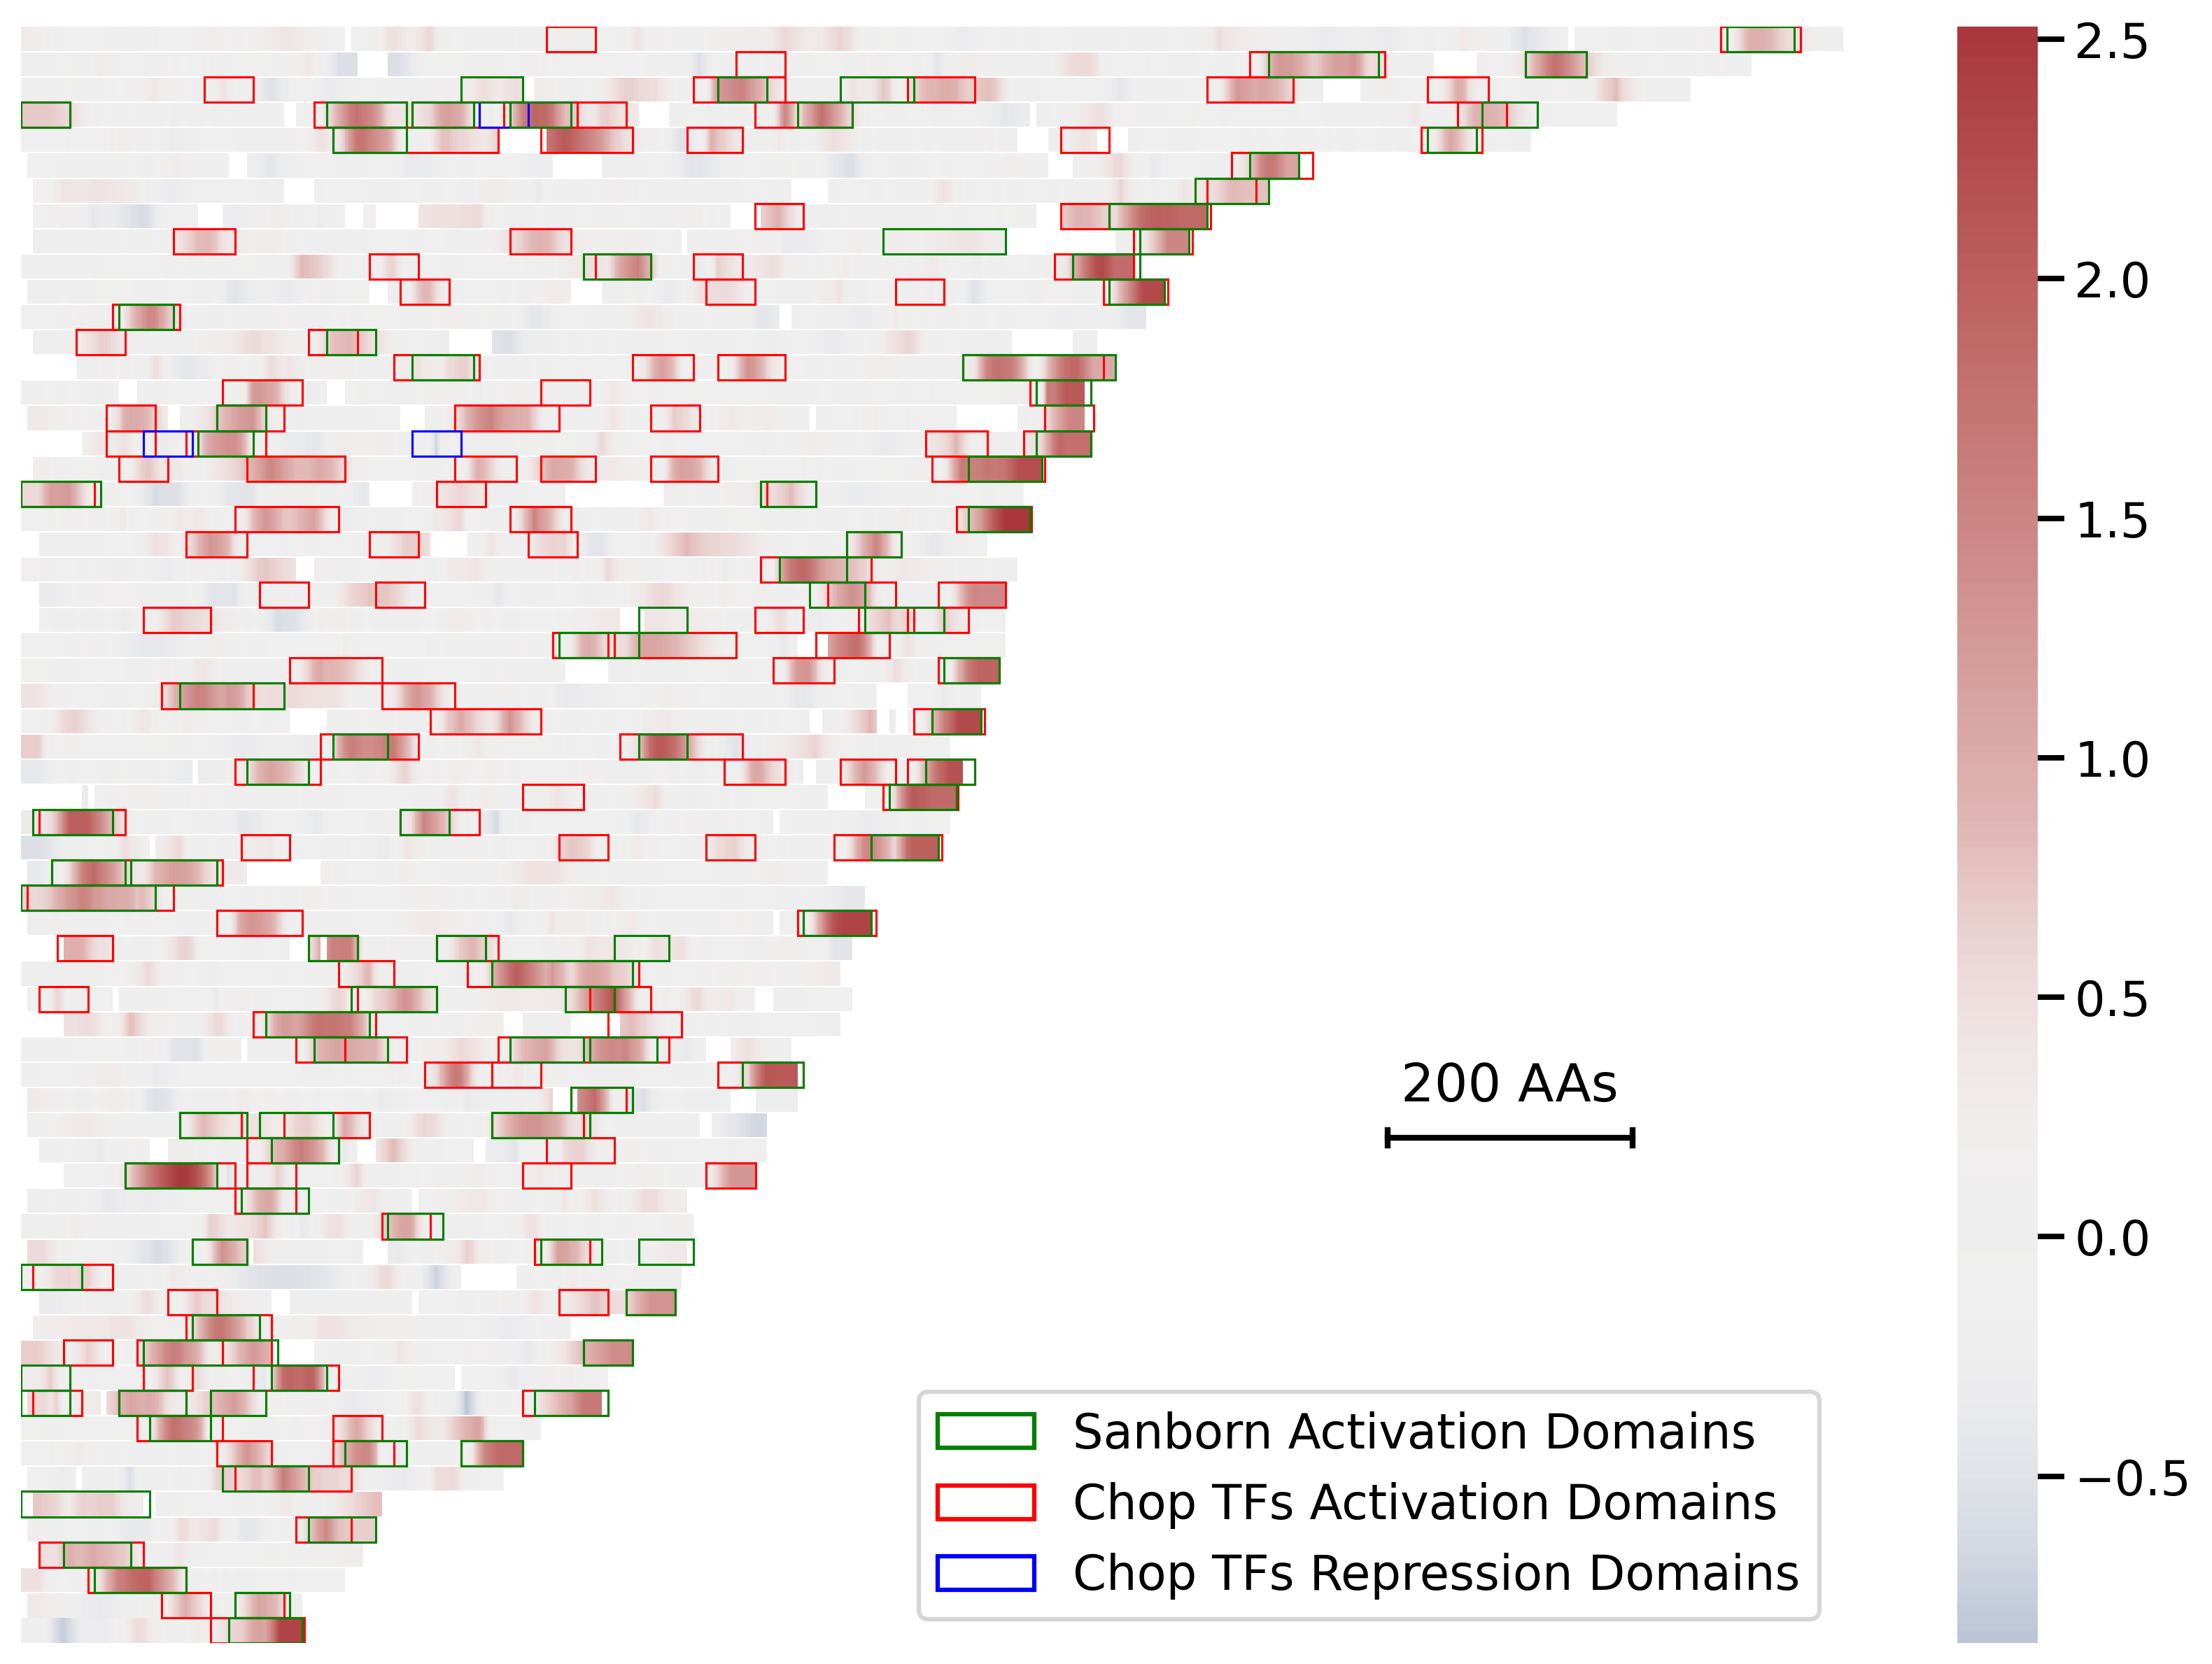

In [108]:
plot_heatmap(mat[mat.index.isin(sanborn["id"])], should_add_boxes=False)
plot_heatmap(mat[mat.index.isin(sanborn["id"])])

# Using loess to get activity

In [109]:
loess_pos["activity_loess_pos"].quantile(0.90)

0.5848858577891315

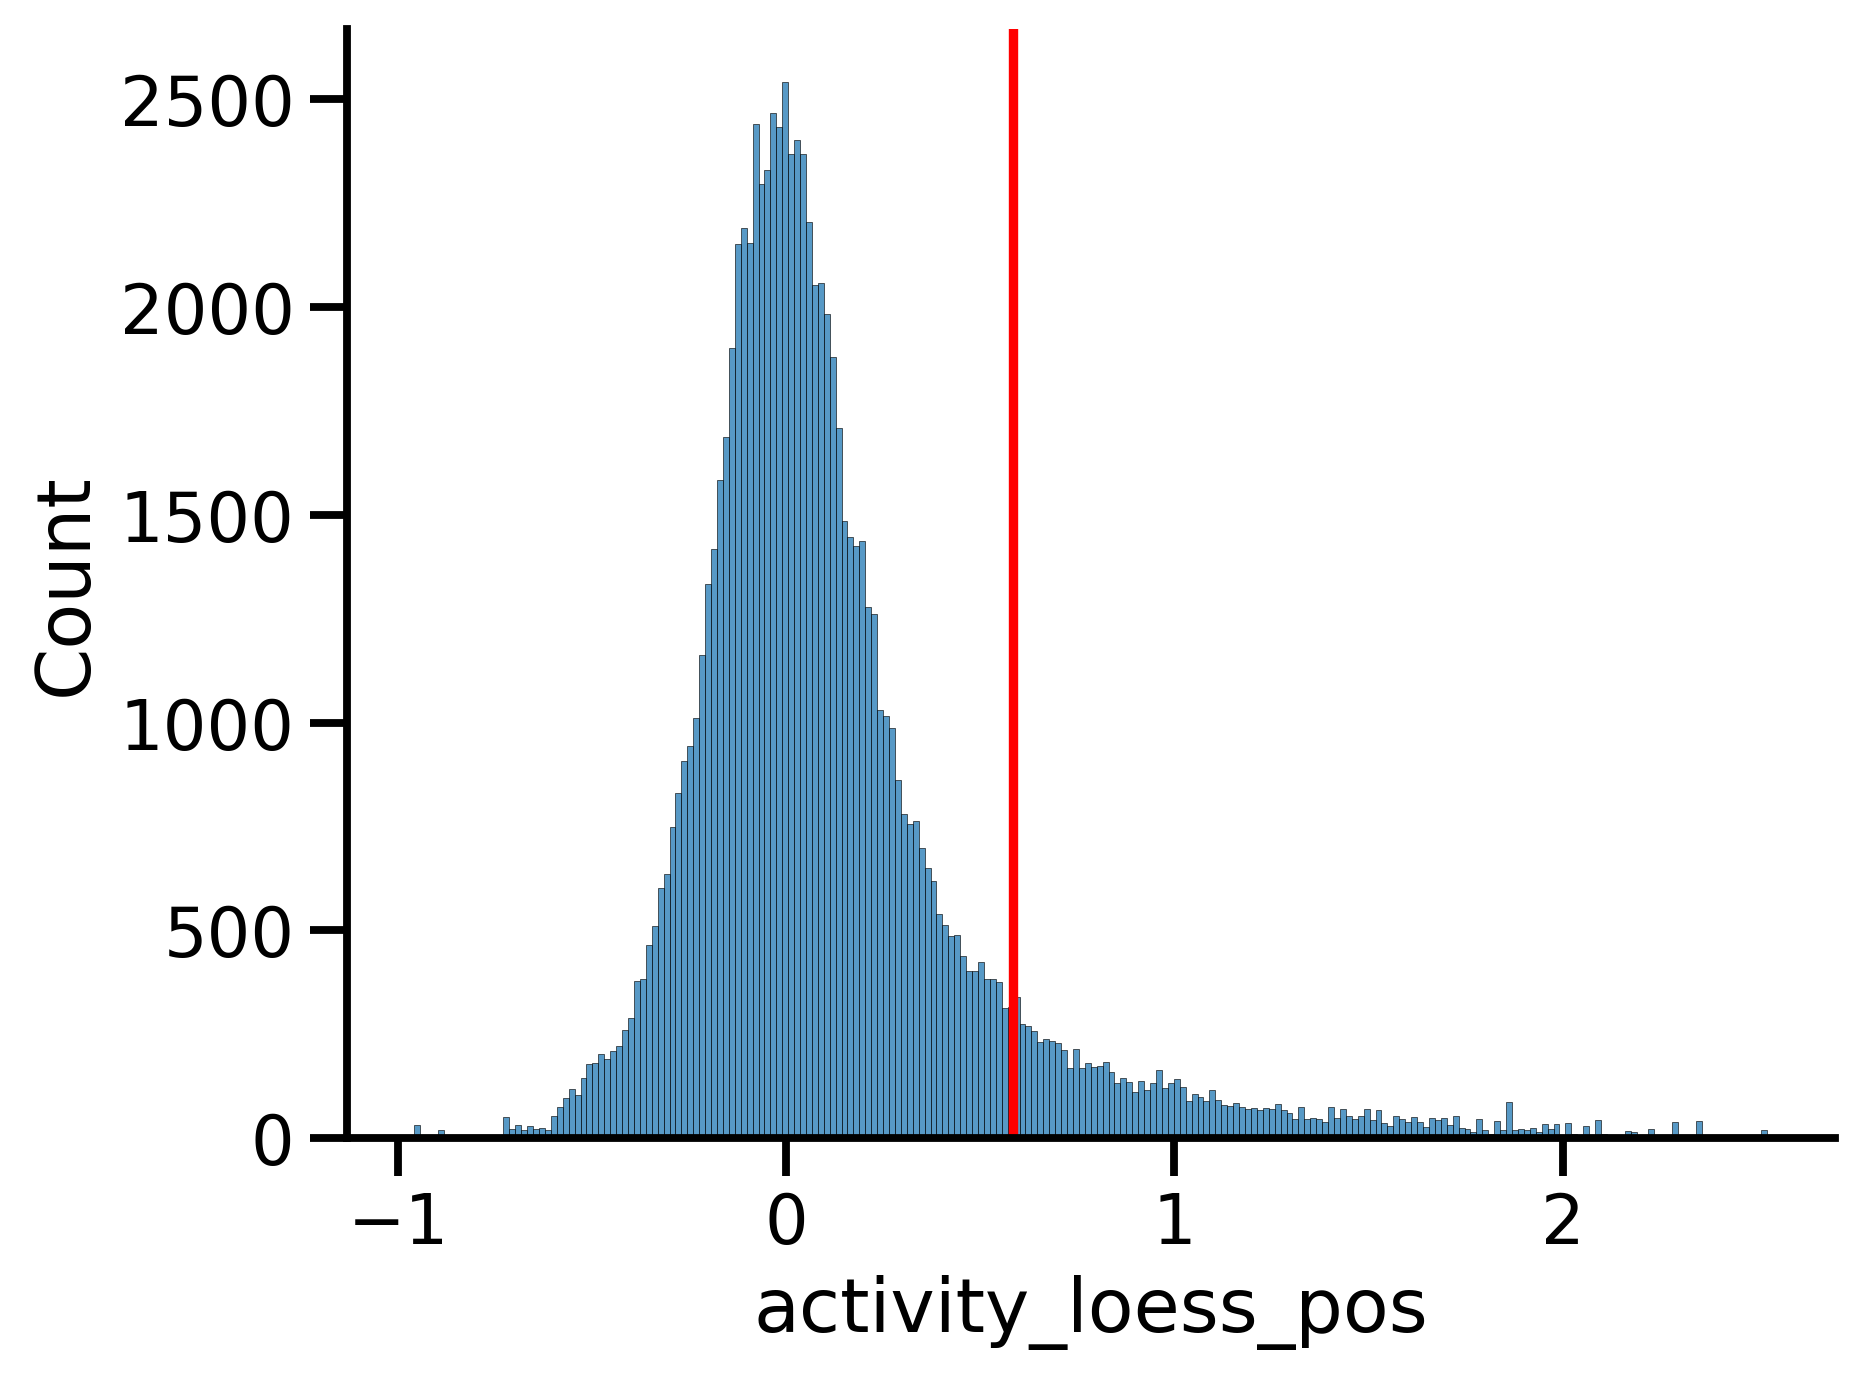

In [110]:
# I will consider positions above 1 to be active- a fold change of 10
plt.figure(dpi = 300)
sns.histplot(data = loess_pos, x = "activity_loess_pos")
plt.axvline(loess_pos["activity_loess_pos"].quantile(0.90), color = 'red')
sns.despine()

Mode: -0.0171
μ = -0.0171, σ = 0.2066
Z-score of 1.0: 4.92
Value at Z=3.5: 0.7058


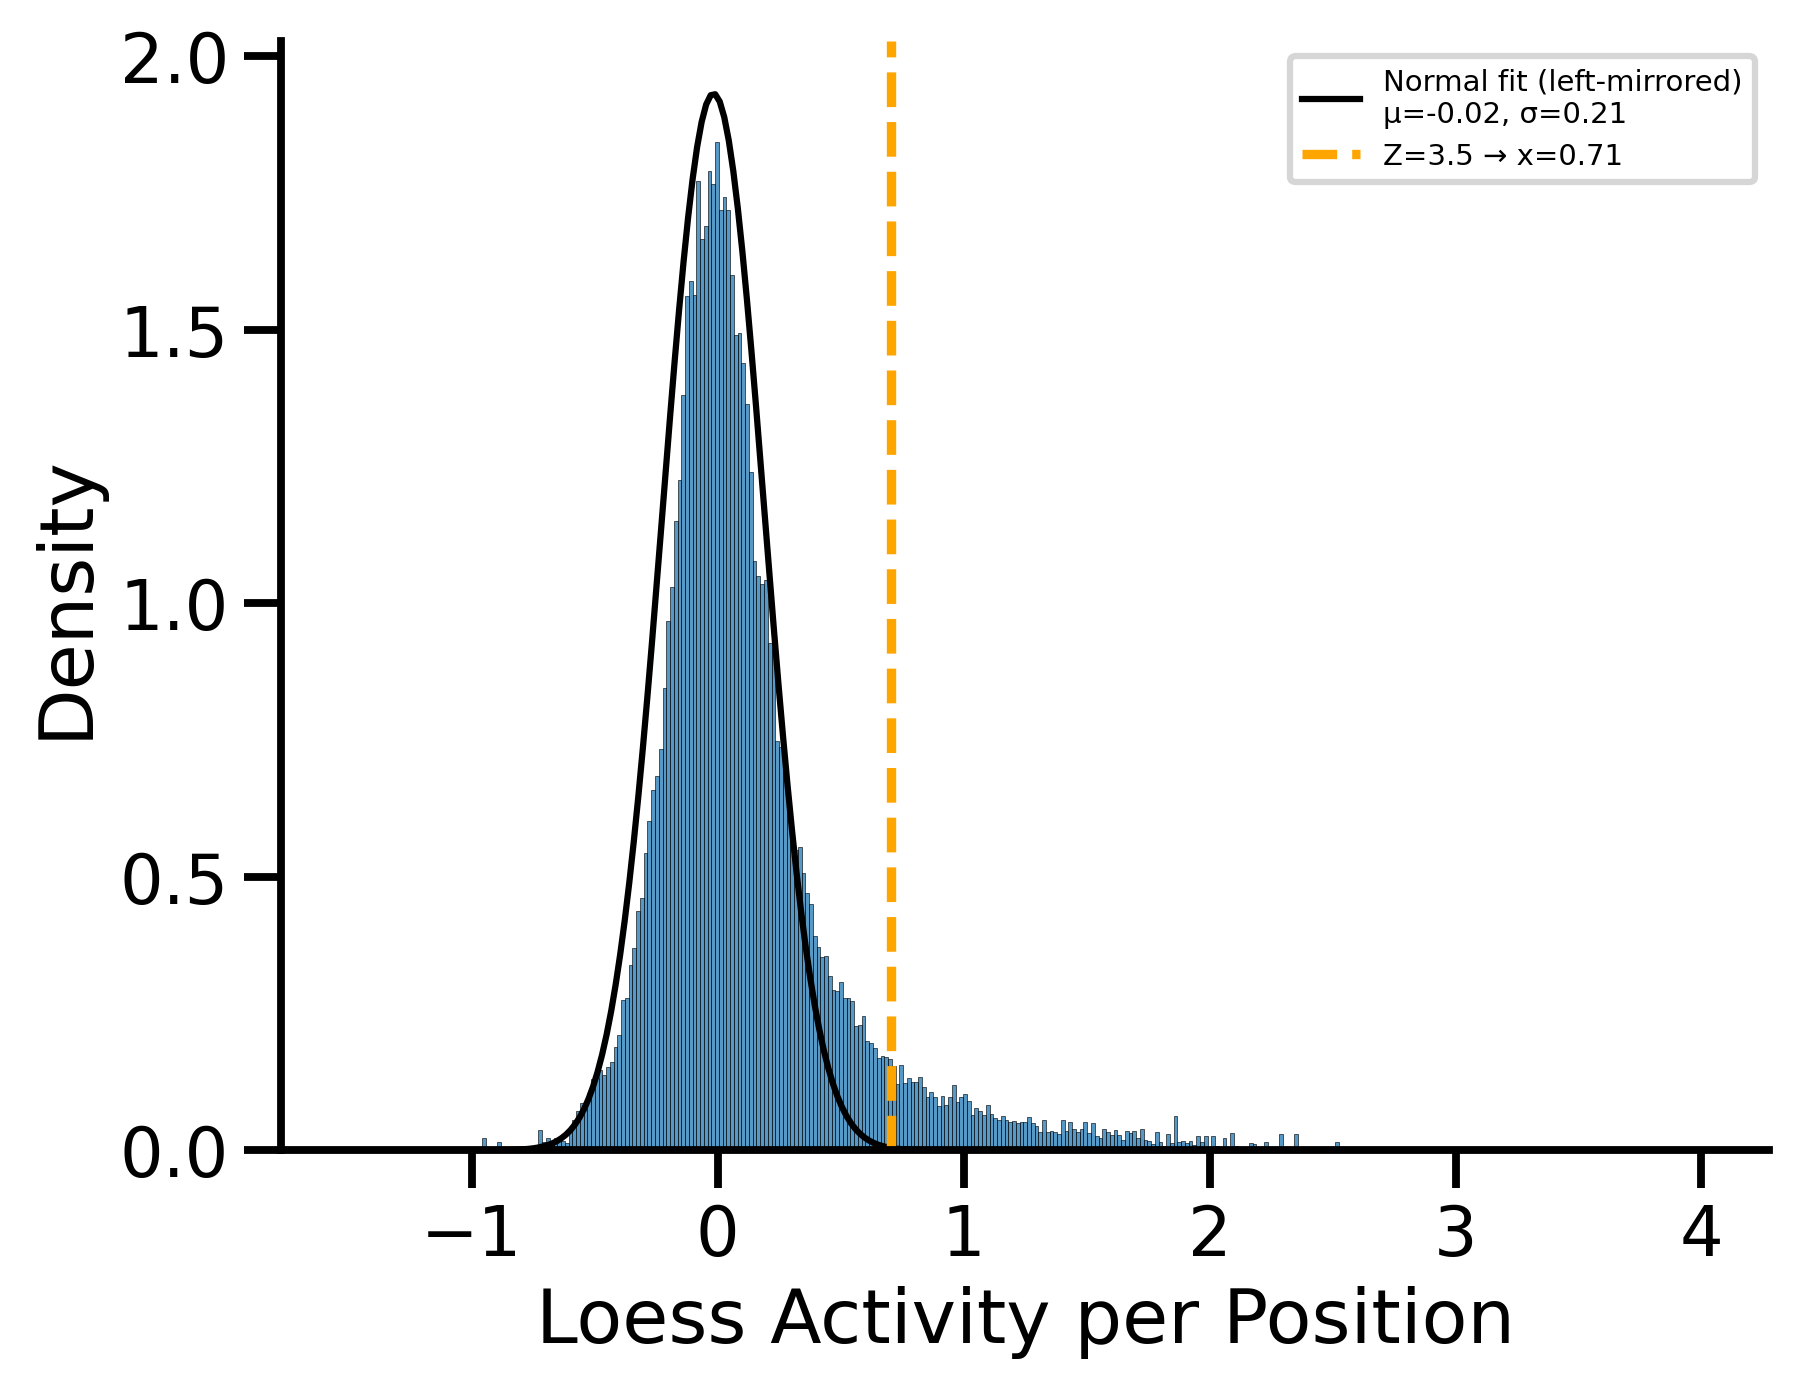

In [136]:
from scipy import stats
import numpy as np

# find mode-ish peak using histogram
counts, bin_edges = np.histogram(loess_pos["activity_loess_pos"], bins=200)
mode_approx = bin_edges[np.argmax(counts)]
print(f"Mode: {mode_approx:.4f}")

# fit normal only to values LEFT of the mode (uncontaminated by active population)
left_side = loess_pos[loess_pos["activity_loess_pos"] <= mode_approx]["activity_loess_pos"]
# mirror it: reflect left side around the mode to get a symmetric sample
mirrored = pd.concat([
    left_side,
    pd.Series(2 * mode_approx - left_side.values)  # reflected right side
])
mu, sigma = stats.norm.fit(mirrored)
print(f"μ = {mu:.4f}, σ = {sigma:.4f}")
print(f"Z-score of 1.0: {(1.0 - mu) / sigma:.2f}")
print(f"Value at Z=3.5: {mu + 3.5 * sigma:.4f}")

# plot
fig, ax = plt.subplots(dpi=300)
sns.histplot(data=loess_pos, x="activity_loess_pos", stat="density", ax=ax)

x = np.linspace(-1.5, 4, 300)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'k-', lw=1.5, 
        label=f'Normal fit (left-mirrored)\nμ={mu:.2f}, σ={sigma:.2f}')
ax.axvline(mu + 3.5 * sigma, color='orange', linestyle='--', 
           label=f'Z=3.5 → x={mu + 3.5*sigma:.2f}')

ax.legend(fontsize=7)
ax.set_xlabel("Loess Activity per Position")
sns.despine()
plt.show()

Searching for ADs as Sanborn did, using Z-score of 3.5 corresponding to a threshold of 0.71

"To define ADs across all TFs, at each protein position a mean Z-score was calculated from the Z-scores of all fragments overlapping that position. ADs were defined for all intervals of the protein that had a mean positional Z-score (MPZ) greater than 3.5. Starting with intervals that had the highest maximal MPZ score, the start and stop positions of the AD were defined by the full width half maximum; that is, the positions in the protein at which the MPZ fell below half of the maximal MPZ value in that interval. If the AD defined in this manner includes a new region with an MPZ score higher than the original maximal value, this indicated that the MPZ peak was only small relative to nearby peaks, so the AD was then excluded."

In [112]:
import numpy as np
import pandas as pd


def find_ads(loess_hc, threshold=3.5):

    ads = []

    for pid, g in loess_hc.groupby("id"):

        g = g.sort_values("position").reset_index(drop=True)

        pos = g["position"].values
        val = g["activity_loess_pos"].values

        # -----------------------------------
        # 1. candidate intervals > threshold
        # -----------------------------------
        above = val > threshold

        if not above.any():
            continue

        starts = np.where(np.diff(np.r_[0, above.astype(int)]) == 1)[0]
        ends = np.where(np.diff(np.r_[above.astype(int), 0]) == -1)[0]

        for s, e in zip(starts, ends):

            interval_pos = pos[s:e+1]
            interval_val = val[s:e+1]

            # -----------------------------------
            # 2. peak in interval
            # -----------------------------------
            peak_idx_local = np.argmax(interval_val)
            peak_val = interval_val[peak_idx_local]
            peak_pos = interval_pos[peak_idx_local]

            # -----------------------------------
            # 3. FWHM boundaries
            # -----------------------------------
            half = peak_val / 2

            global_peak_idx = s + peak_idx_local

            # left boundary
            left = global_peak_idx
            while left > 0 and val[left] >= half:
                left -= 1

            # right boundary
            right = global_peak_idx
            while right < len(val)-1 and val[right] >= half:
                right += 1

            ad_start = pos[left + 1]
            ad_end = pos[right - 1]

            # -----------------------------------
            # 4. shoulder rejection
            # -----------------------------------
            inside = (pos >= ad_start) & (pos <= ad_end)

            if val[inside].max() > peak_val:
                continue

            ads.append({
                "id": pid,
                "ad_start": ad_start,
                "ad_end": ad_end,
                "length": ad_end - ad_start + 1,
                "peak_pos": peak_pos,
                "peak_activity": peak_val,
            })

    return pd.DataFrame(ads)

In [113]:
stricter_ads = find_ads(loess_pos, threshold=0.71)

stricter_ads_intervals = (
    stricter_ads[["id", "ad_start", "ad_end"]]
    .rename(columns={
        "ad_start": "tile_start",
        "ad_end": "tile_end"
    })
)

stricter_ads_merged = merge_intervals(stricter_ads_intervals)

compare_intervals(
    stricter_ads_merged,
    sanborn_merged,
    names=("Stricter ADs", "Sanborn")
)

Stricter ADs intervals overlapping Sanborn: 93 / 233 (39.9%)
Stricter ADs intervals missed by Sanborn:  140 / 233 (60.1%)
Sanborn intervals overlapping Stricter ADs: 87 / 98 (88.8%)
Sanborn intervals missed by Stricter ADs:  11 / 98 (11.2%)


array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [114]:
compare_intervals(
    stricter_ads_merged,
    our_repressors_merged,
    names=("Stricter ADs", "Repressors")
)

Stricter ADs intervals overlapping Repressors: 2 / 233 (0.9%)
Stricter ADs intervals missed by Repressors:  231 / 233 (99.1%)
Repressors intervals overlapping Stricter ADs: 2 / 13 (15.4%)
Repressors intervals missed by Stricter ADs:  11 / 13 (84.6%)


array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [115]:
compare_intervals(
    sanborn_merged,
    our_repressors_merged,
    names=("Sanborn ADs", "RDs")
)

Sanborn ADs intervals overlapping RDs: 1 / 98 (1.0%)
Sanborn ADs intervals missed by RDs:  97 / 98 (99.0%)
RDs intervals overlapping Sanborn ADs: 1 / 13 (7.7%)
RDs intervals missed by Sanborn ADs:  12 / 13 (92.3%)


array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

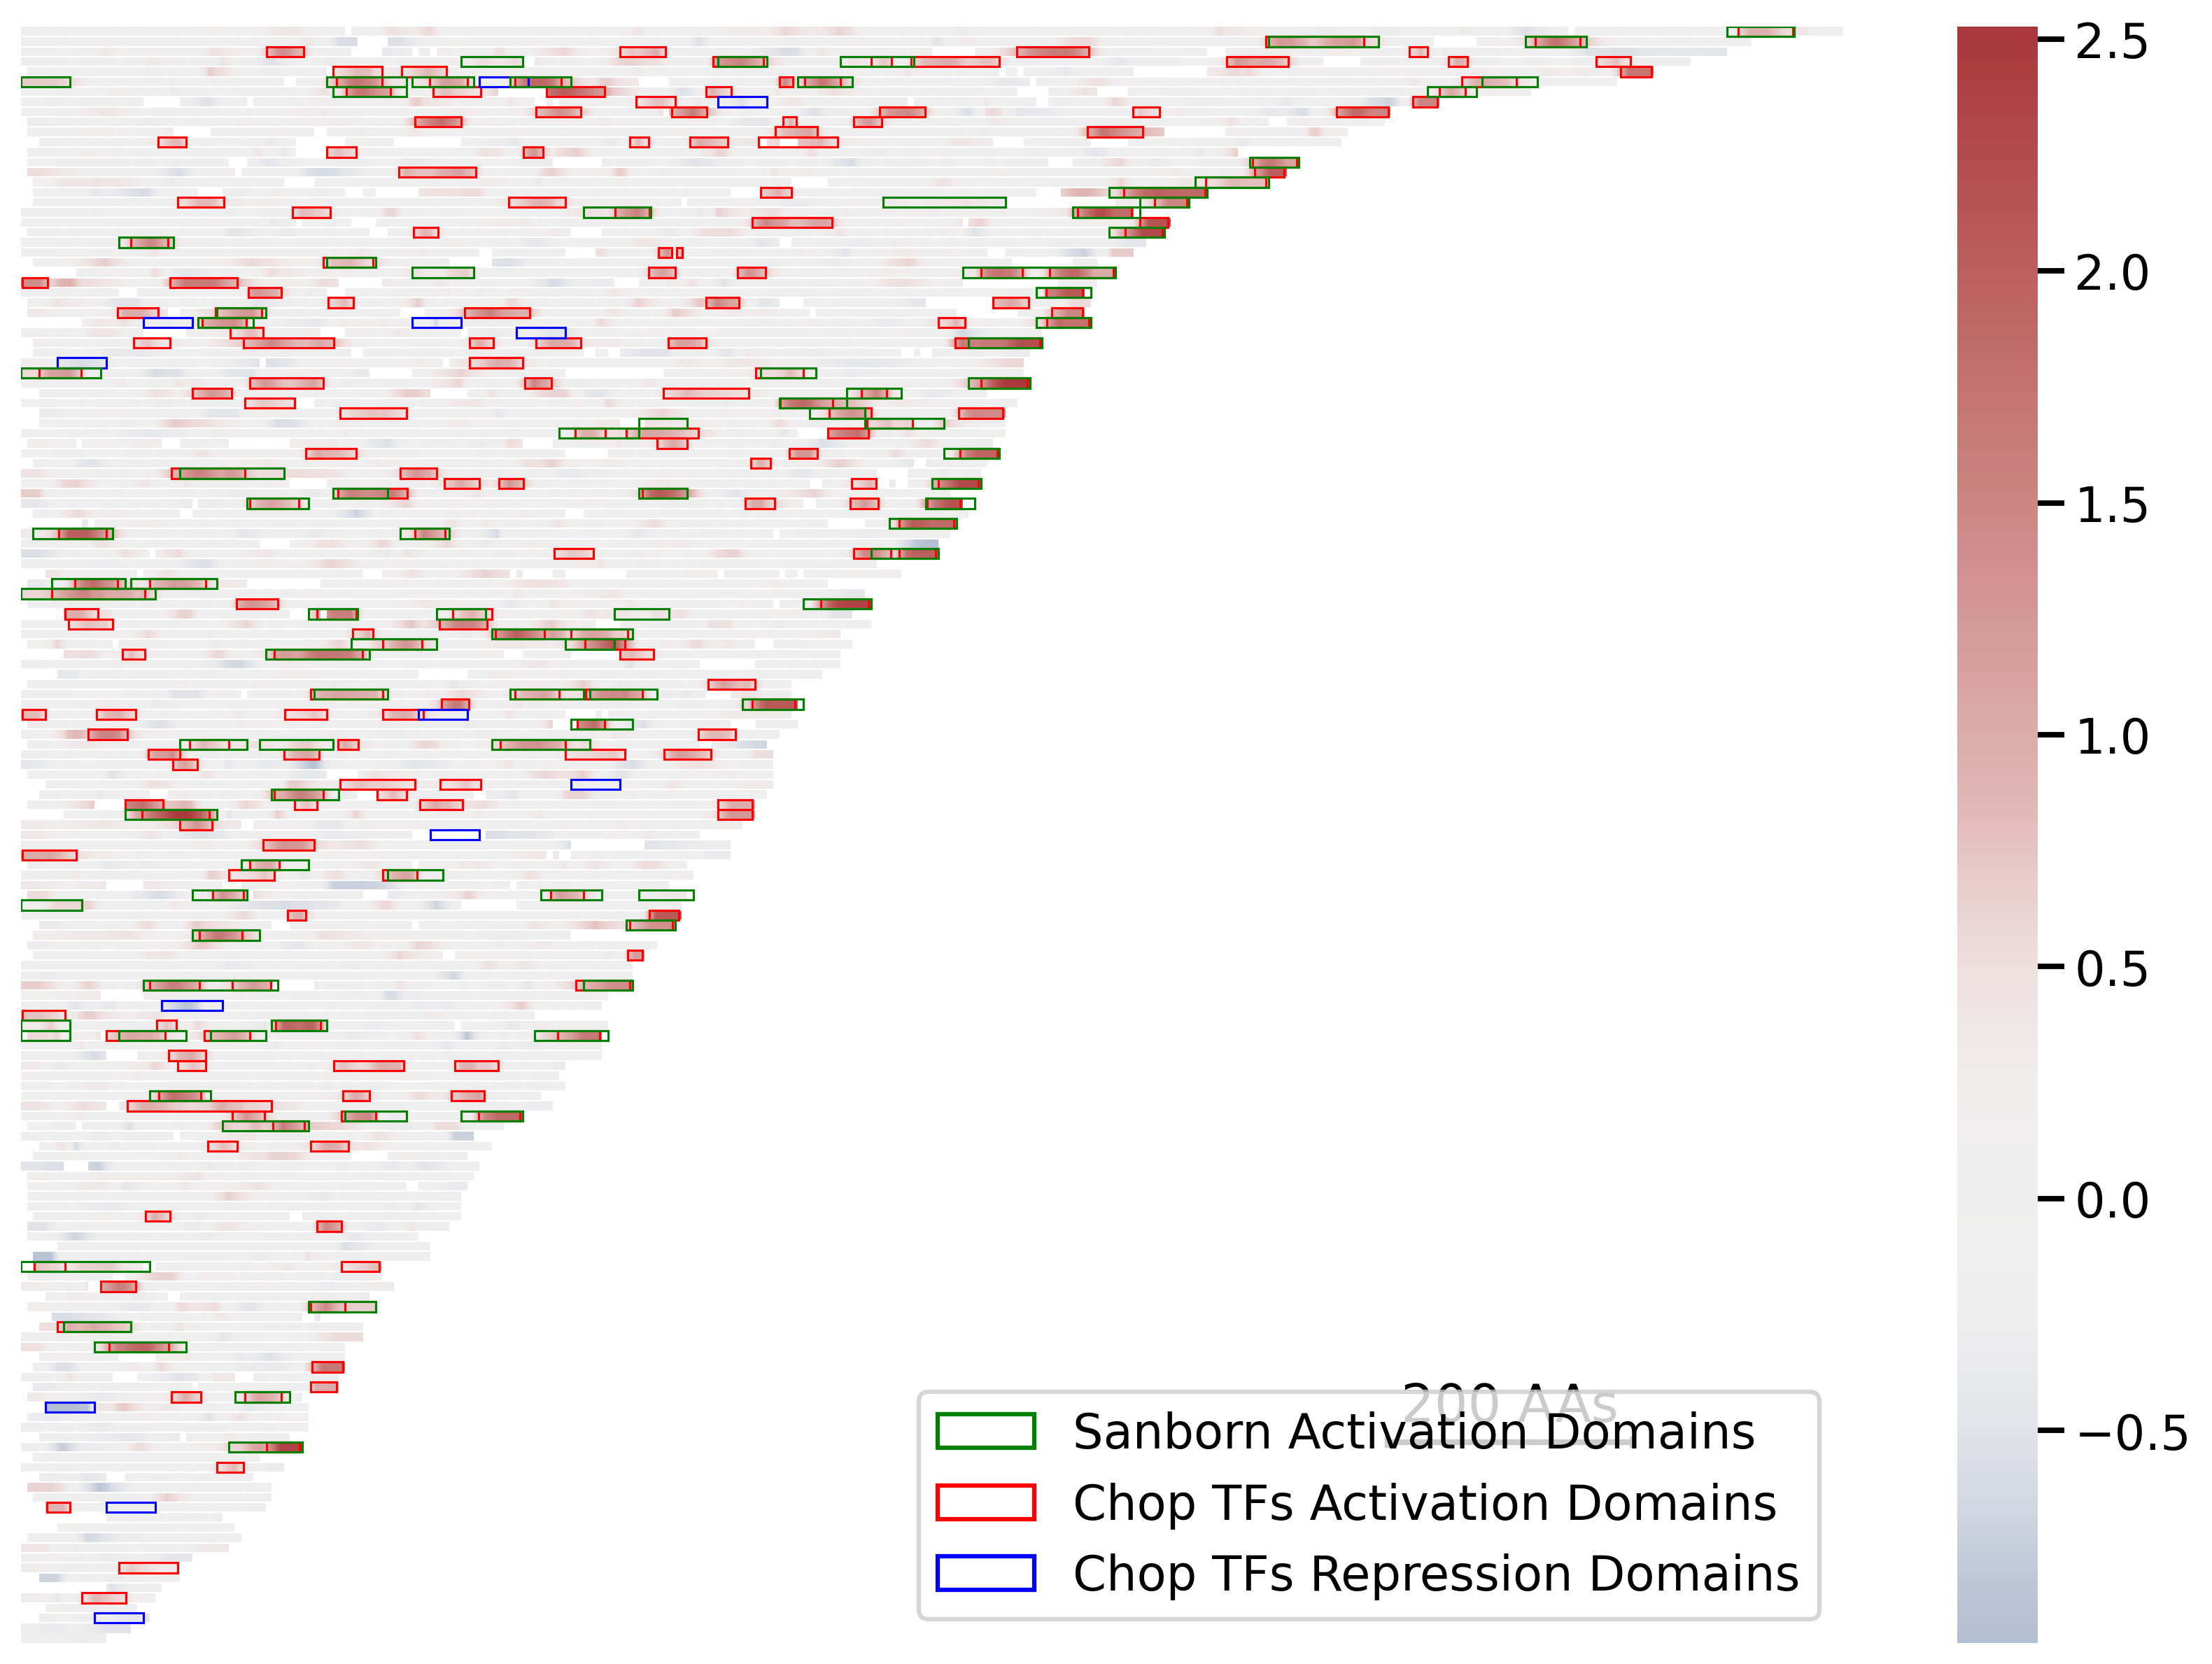

In [119]:
plot_heatmap(mat, 
             should_add_boxes=True, 
             ADs = stricter_ads_merged)

In [117]:
ids = set(sanborn["id"]) | set(pd.DataFrame(stricter_ads_merged)[0]) | set(pd.DataFrame(our_repressors_merged)[0])

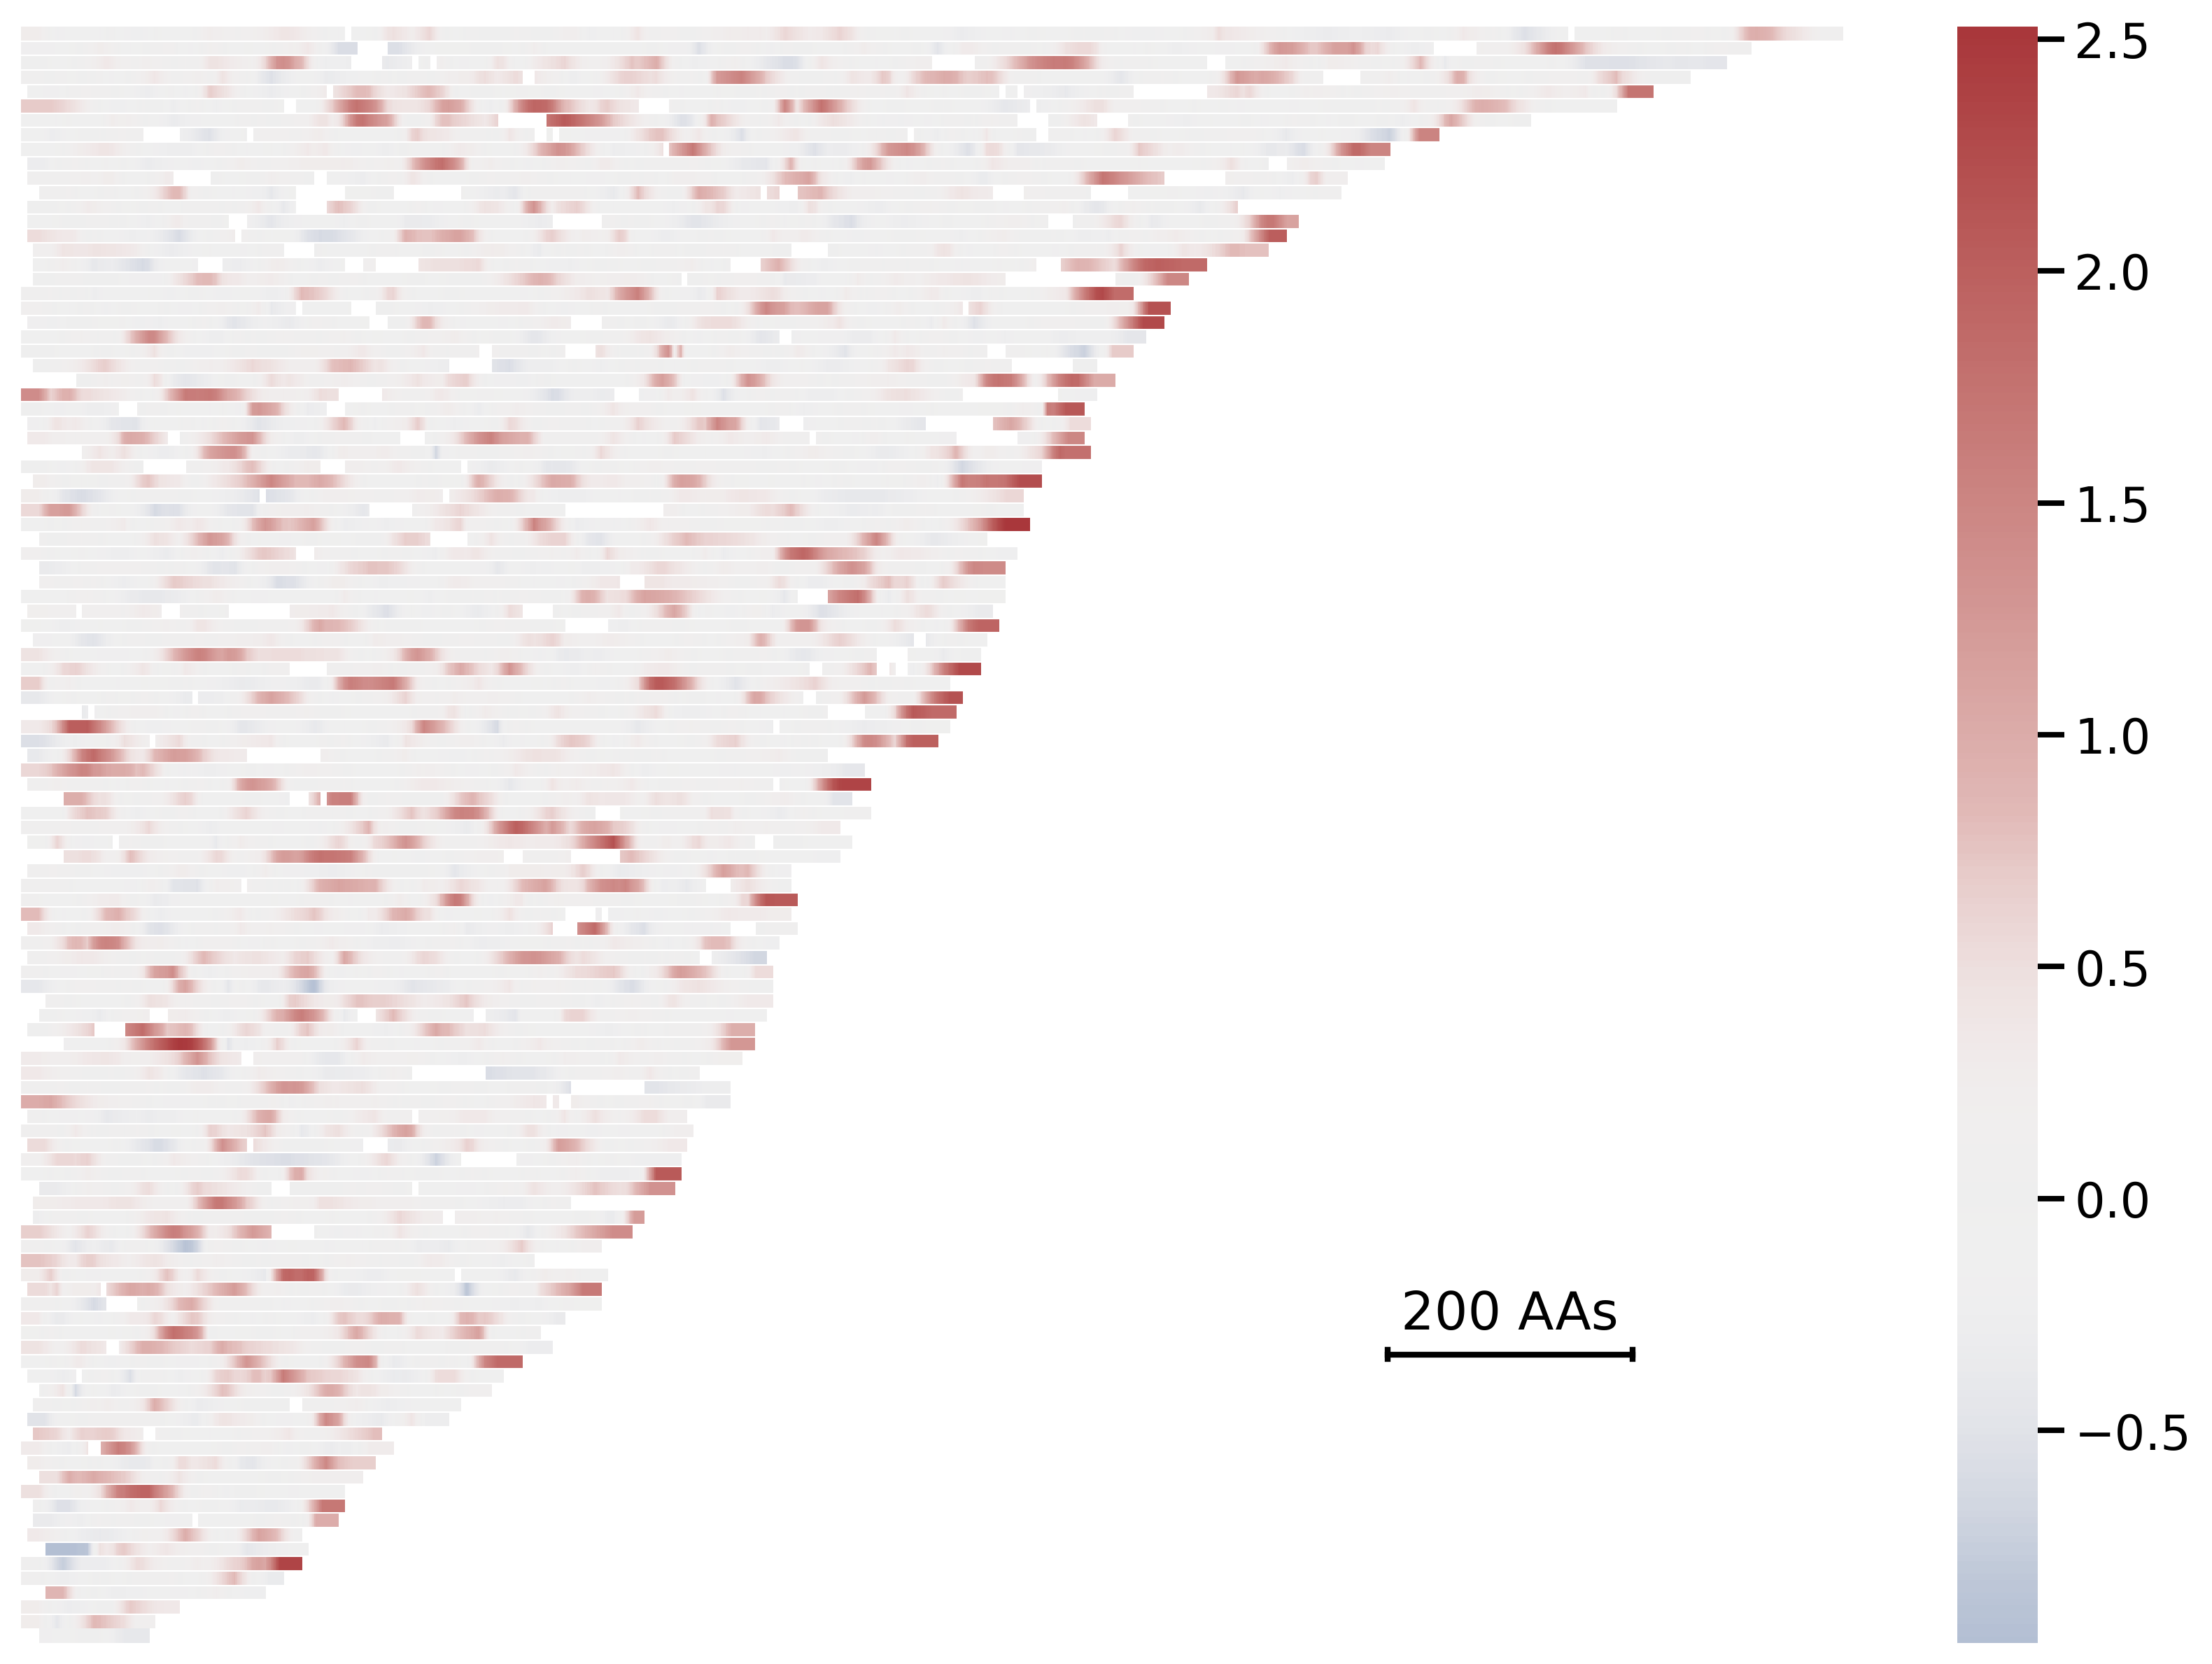

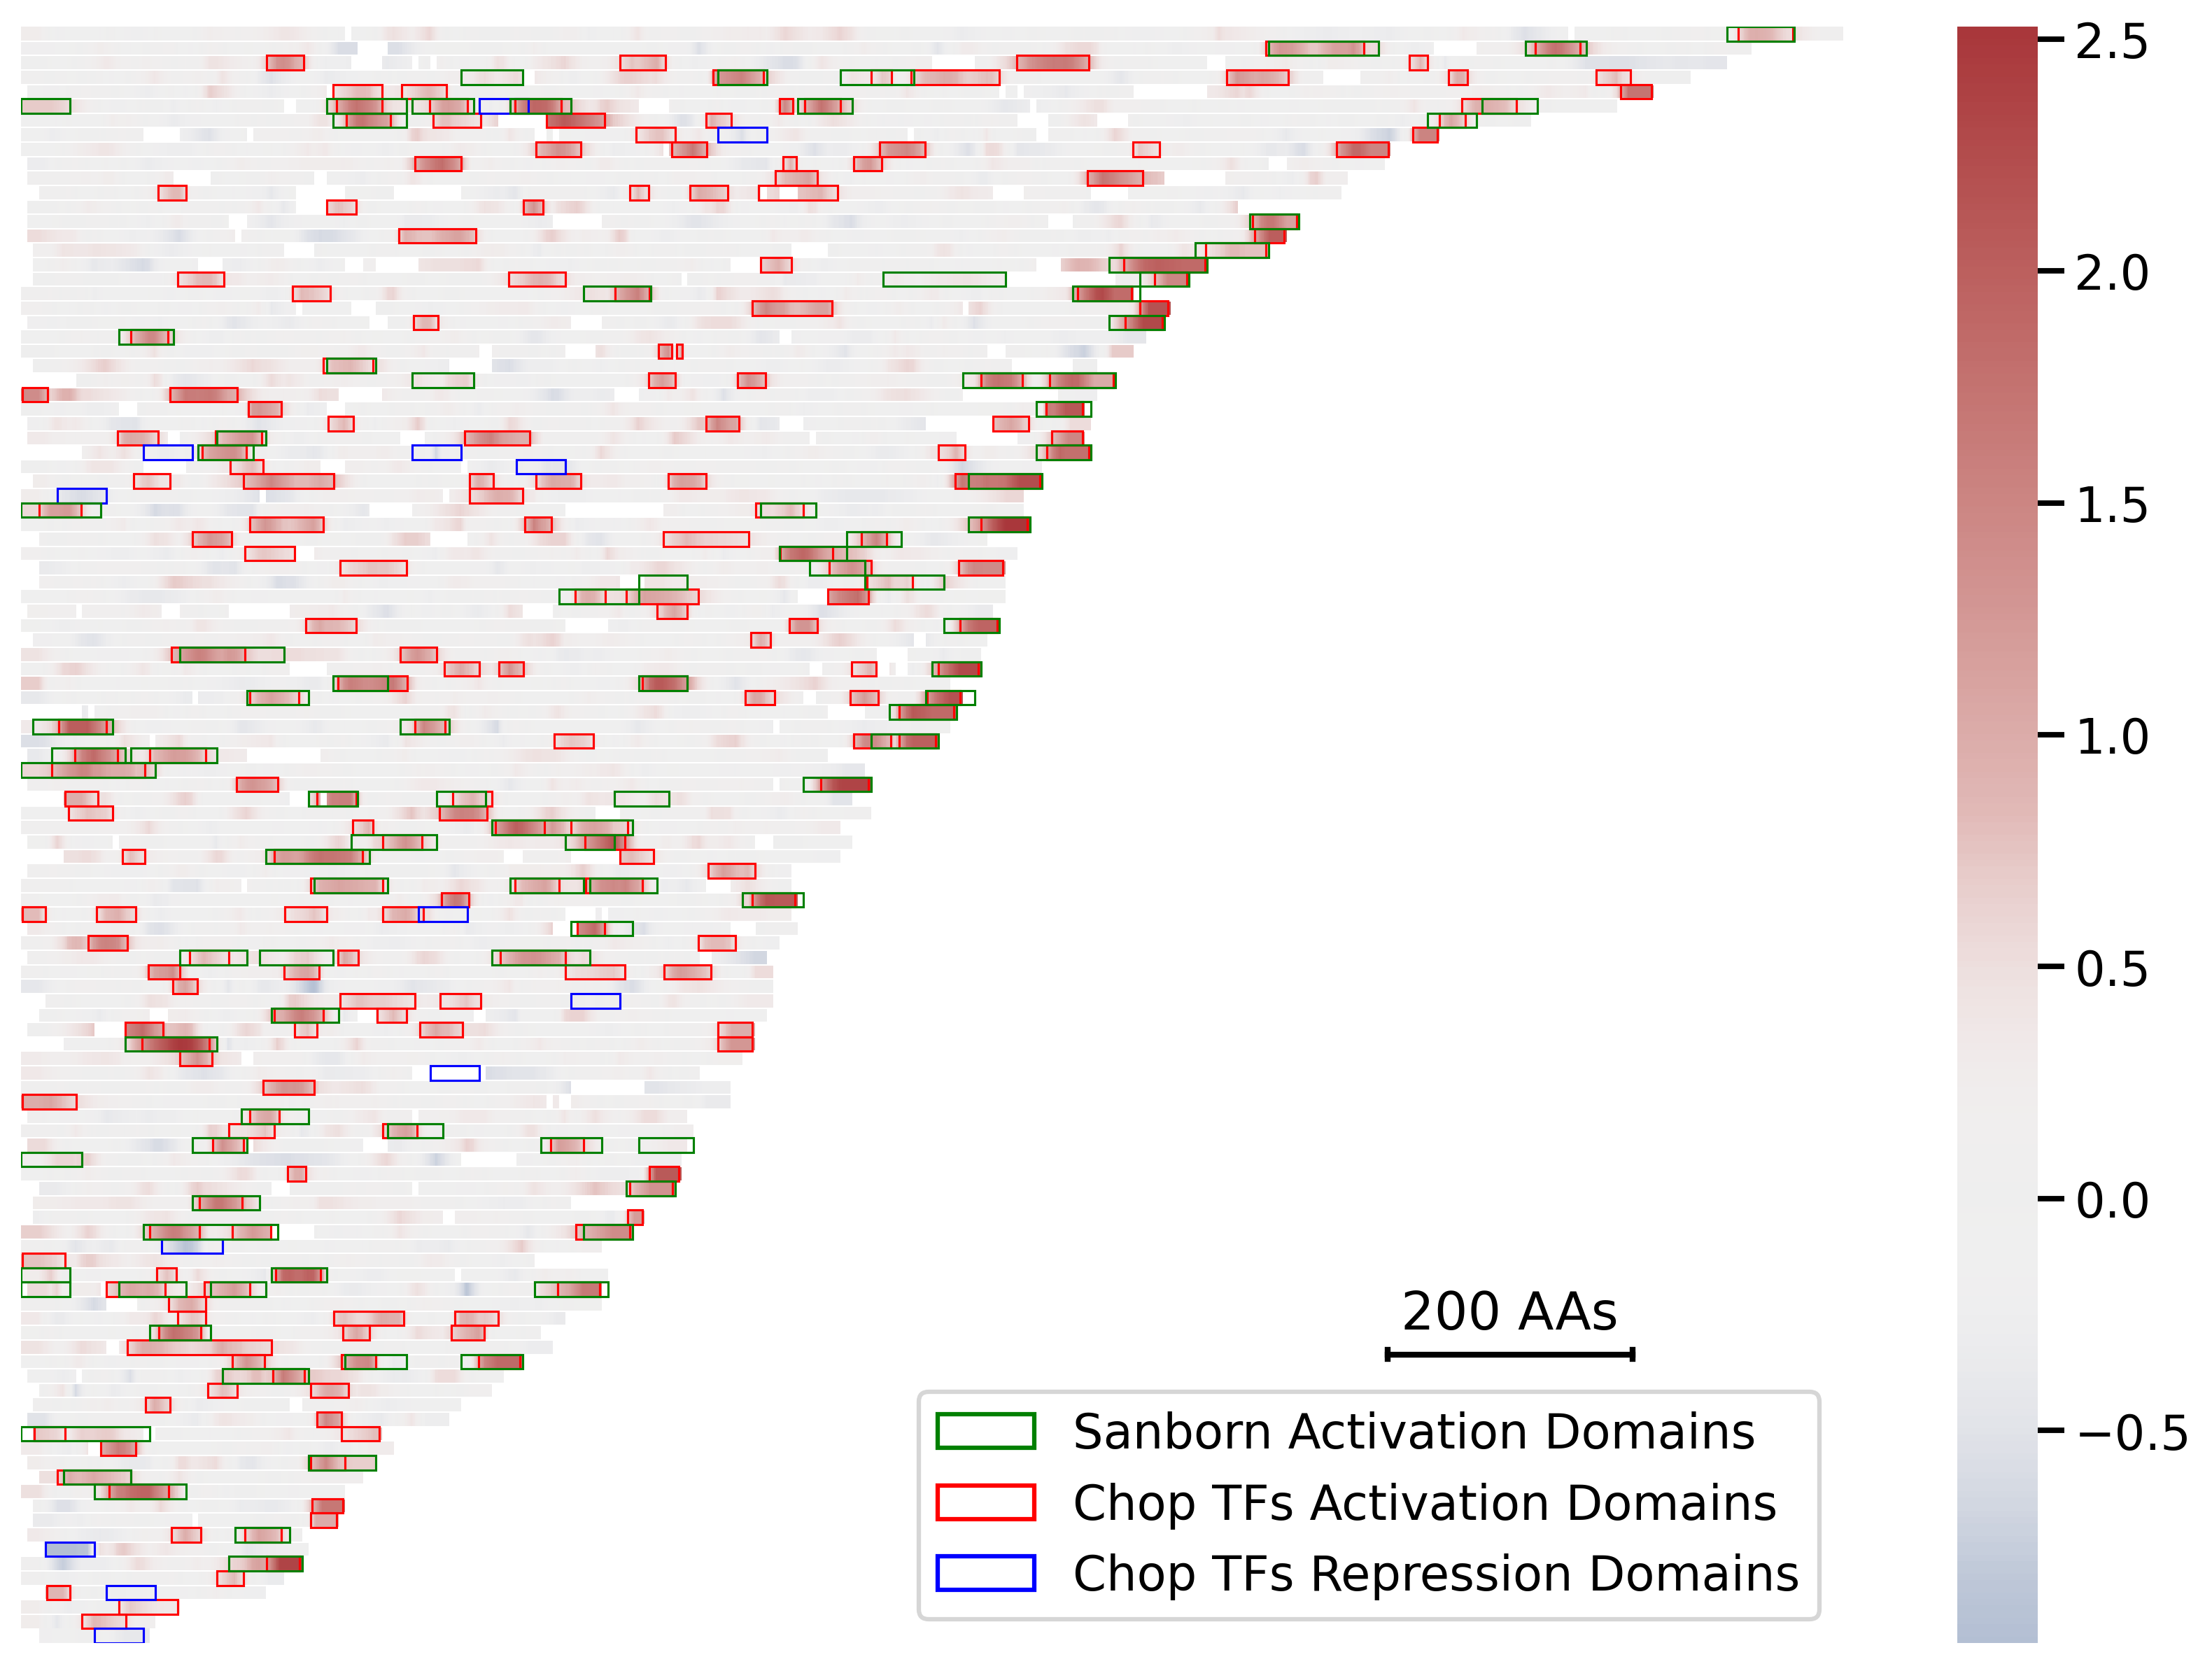

In [118]:
plot_heatmap(
    mat[mat.index.isin(ids)],
    should_add_boxes=False
)
plot_heatmap(
    mat[mat.index.isin(ids)],
    should_add_boxes=True,              
    ADs = stricter_ads_merged
)


In [88]:
# Only 2 of our ADs lie within TFs which are known repressors
set(pd.DataFrame(our_activators_merged)[0]) & set(RD_ids)

{'YKL038W', 'YNL216W'}

In [89]:
len(set(pd.DataFrame(our_activators_merged)[0]))

112

In [90]:
len(set(RD_ids))

8

# Saving for use in other notebook

In [134]:
import pickle

mat.to_pickle("../../../data/ChopTFs_sanborn/mat.pkl")

with open("../../../data/ChopTFs_sanborn/our_activators_merged.pkl", "wb") as f:
    pickle.dump(our_activators_merged, f)
with open("../../../data/ChopTFs_sanborn/our_repressors_merged.pkl", "wb") as f:
    pickle.dump(our_repressors_merged, f)
with open("../../../data/ChopTFs_sanborn/sanborn_merged.pkl", "wb") as f:
    pickle.dump(sanborn_merged, f)
with open("../../../data/ChopTFs_sanborn/stricter_ads_merged.pkl", "wb") as f:
    pickle.dump(stricter_ads_merged, f)